# LArXe Pulse Shape Study (Liq. #7)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.fft import fft, ifft
import pandas as pd
import glob
import sipm.util.functions as func
from datetime import datetime
from scipy.optimize import least_squares
plt.style.use('darkside')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
!pwd

/home/as111/sipm-analysis/jupyter


# SPE Pulse Shape

In [2]:
# data folder
path = "/scratch/gpfs/GALBIATI/as111/results/2023-12-13"
data_spe = {}
channels = np.arange(8)
volt = 98
for ch in channels:
    data_spe[ch] = {'n_spe_wfs':0, 'avg_spe_wf':np.zeros(0), 'time':np.zeros(0)}
    files = glob.glob(f"{path}/*volt_{volt}*laser_waveform_liq5.h5")
    print(files)
    for f in files:
        df = pd.read_hdf(f, key=f'{volt}/{ch}')
        data_spe[ch]['n_spe_wfs'] += np.array(df['n_spe_wfs'])[0]
        if data_spe[ch]['time'].shape[0]==0:
            data_spe[ch]['time'] = np.array(df['time'])
        if np.array(df['n_spe_wfs'])[0]>0:
            if data_spe[ch]['avg_spe_wf'].shape[0]==0:
                data_spe[ch]['avg_spe_wf'] = np.array(df['avg_spe_wf'])*np.array(df['n_spe_wfs'])[0]
            else:
                data_spe[ch]['avg_spe_wf'] += np.array(df['avg_spe_wf'])*np.array(df['n_spe_wfs'])[0]
    df = None
    if data_spe[ch]['n_spe_wfs']>0:
        data_spe[ch]['avg_spe_wf'] /= data_spe[ch]['n_spe_wfs']
    # extend laser waveform from 4000 samp to 5000 samp
    data_spe[ch]['time'] = np.concatenate([data_spe[ch]['time'],np.arange(4000,5000,1)*0.004])
    data_spe[ch]['avg_spe_wf'] = np.concatenate([data_spe[ch]['avg_spe_wf'],np.zeros(1000)])

['/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run0_laser_waveform_liq5.h5', '/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run5_laser_waveform_liq5.h5', '/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run3_laser_waveform_liq5.h5', '/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run4_laser_waveform_liq5.h5', '/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run8_laser_waveform_liq5.h5', '/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run2_laser_waveform_liq5.h5', '/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run9_laser_waveform_liq5.h5', '/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run6_laser_waveform_liq5.h5', '/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-1

ch0 98V 52313 waveforms selected. Trigger position = 6.364000 us
ch1 98V 81455 waveforms selected. Trigger position = 6.364000 us
ch2 98V 71758 waveforms selected. Trigger position = 6.364000 us
ch3 98V 93199 waveforms selected. Trigger position = 6.364000 us
ch4 98V 97203 waveforms selected. Trigger position = 6.364000 us
ch5 98V 80383 waveforms selected. Trigger position = 6.364000 us
ch6 98V 35771 waveforms selected. Trigger position = 6.364000 us
ch7 98V 30426 waveforms selected. Trigger position = 6.368000 us


Text(0.07, 0.5, 'Amplitude (ADC Unit)')

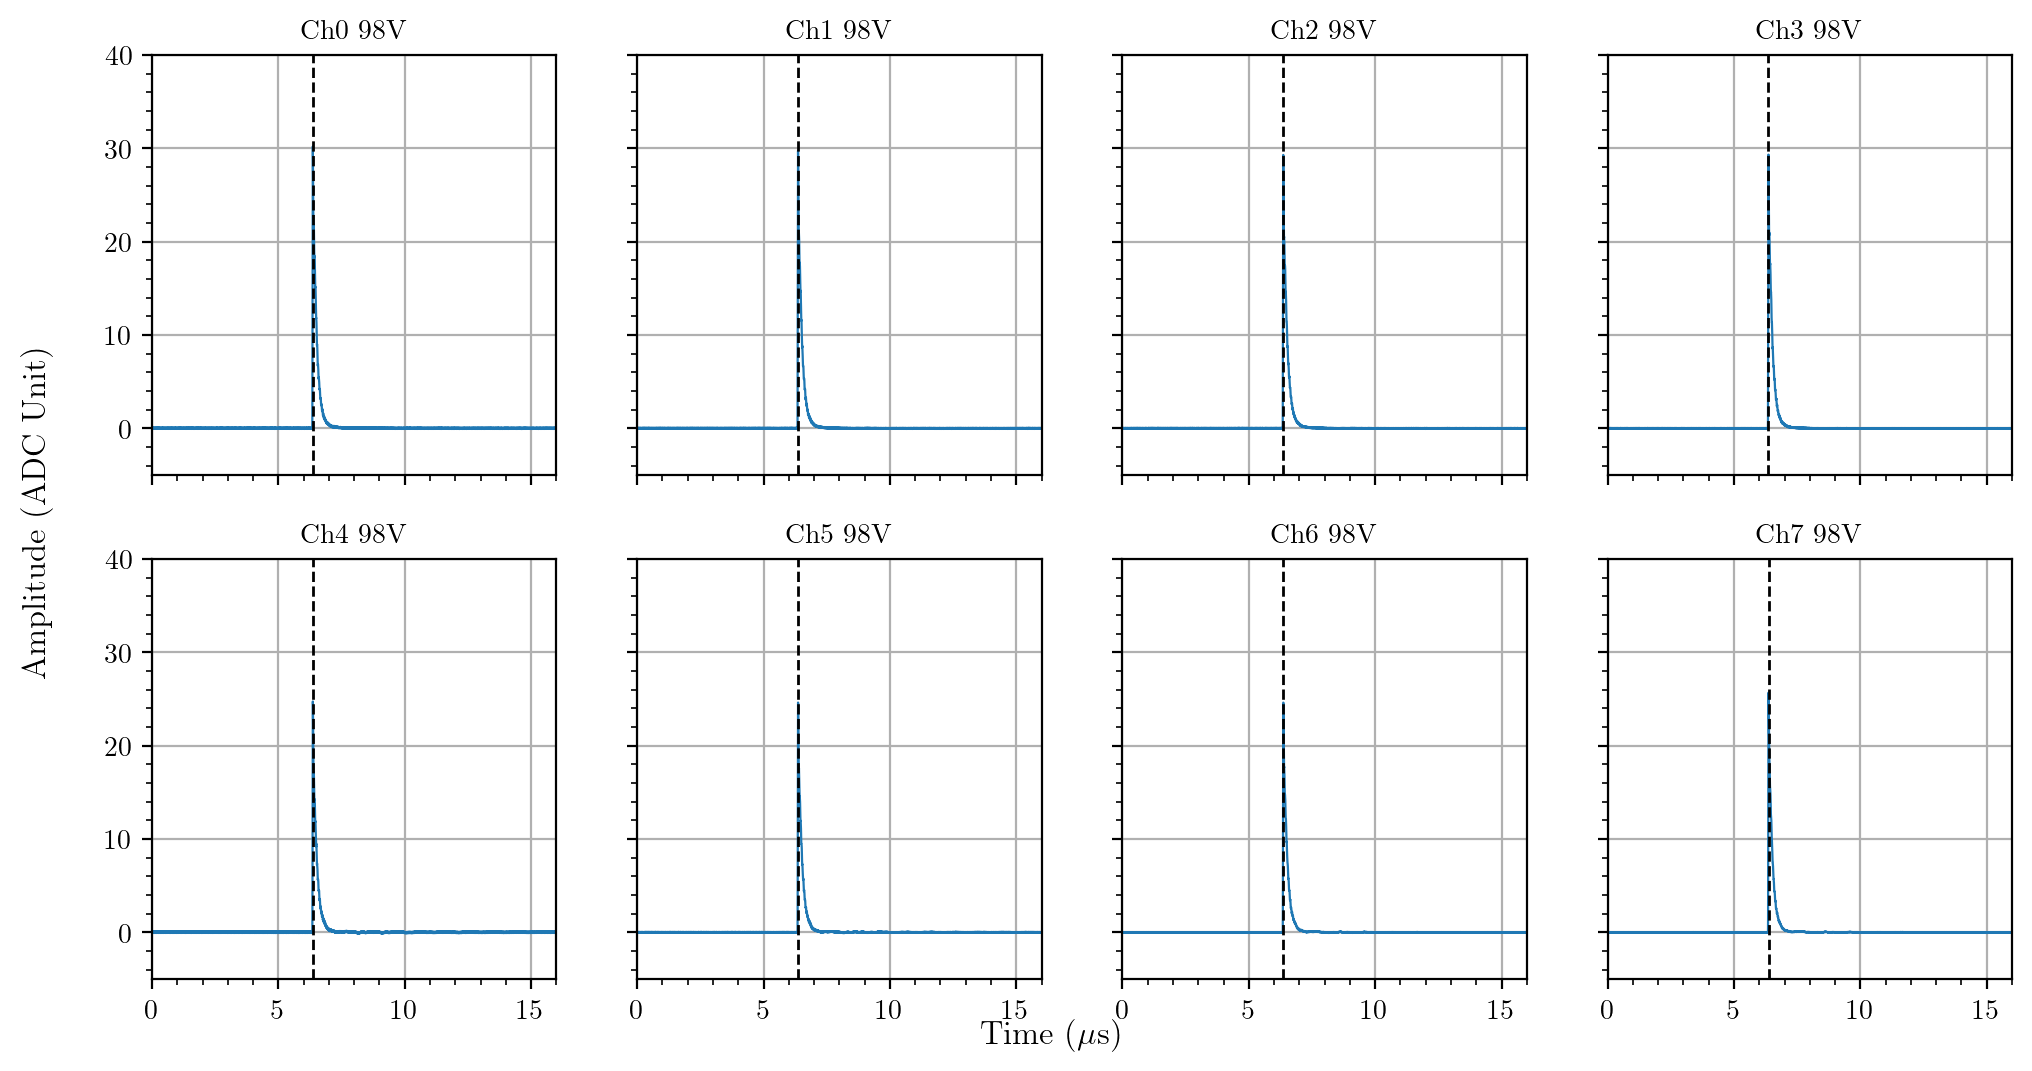

In [3]:
# Make plots for all datasets
# SPE average waveform
t0_spe = {}
fig, axs = plt.subplots(2, 4, sharex=True, sharey=True)
fig.set_size_inches(12, 6)
for j, ch in enumerate(channels):
    if data_spe[ch]['n_spe_wfs']>0:
        t0_spe[ch] = data_spe[ch]['time'][np.argmax(data_spe[ch]['avg_spe_wf'])]
        print(f'ch{ch} {volt}V {data_spe[ch]["n_spe_wfs"]:.0f} waveforms selected. Trigger position = {t0_spe[ch]:2f} us')
        axs[j//4, j%4].plot(
            data_spe[ch]['time'],
            data_spe[ch]['avg_spe_wf'],linewidth=0.8)
    axs[j//4, j%4].set_xlim(0, 16)
    axs[j//4, j%4].set_ylim(-5, 40)
    axs[j//4, j%4].minorticks_on()
    axs[j//4, j%4].grid()
    axs[j//4, j%4].set_title(f'Ch{ch} {volt}V')
    axs[j//4, j%4].plot([t0_spe[ch]]*2, [-5,40], 'k--', lw=1)
fig.supxlabel(r'Time ($\mu$s)', y=0.05)
fig.supylabel(r'Amplitude (ADC Unit)', x=0.07)

## FFT

Text(0.07, 0.5, 'FFT Abs. Amplitude (ADC Unit)')

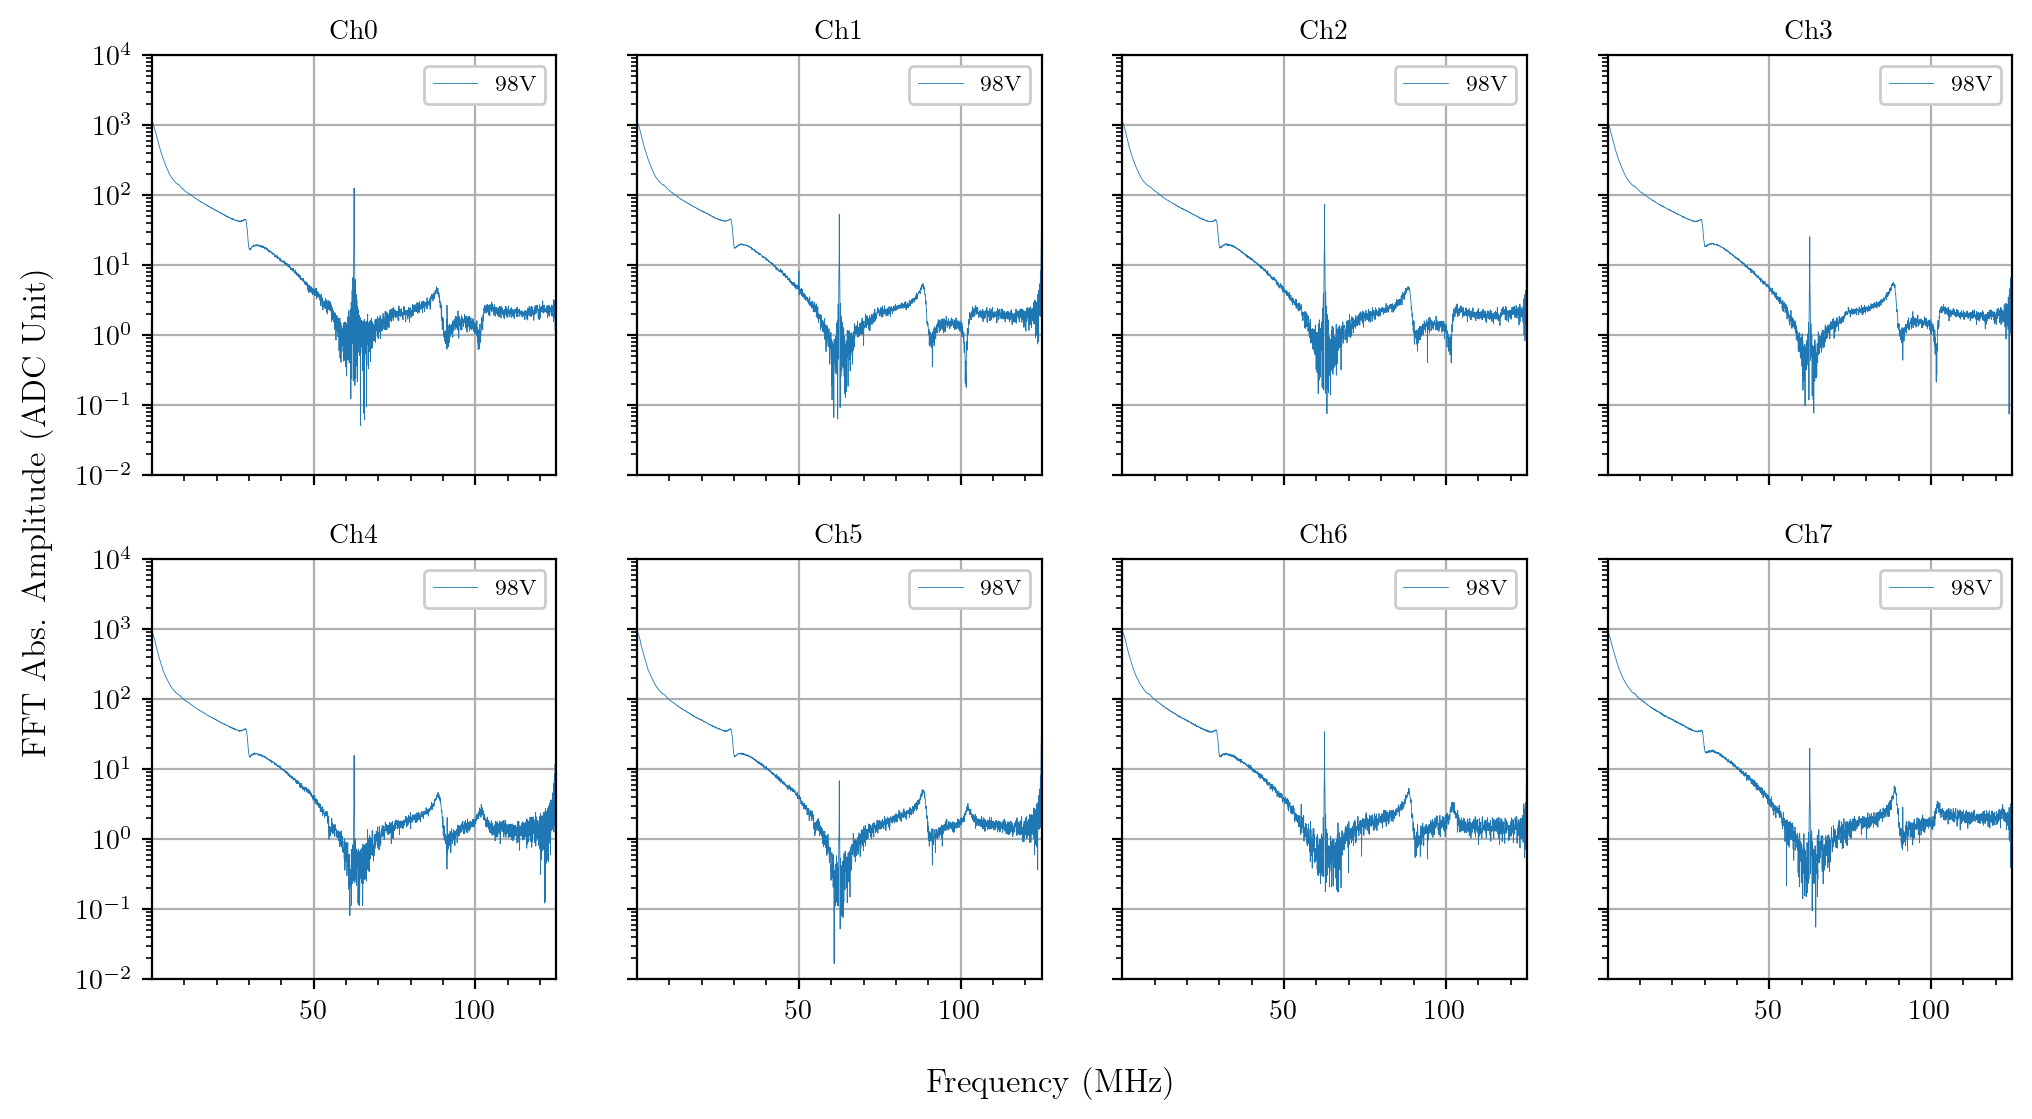

In [4]:
# Make plots for all datasets
# SPE average waveform
fig, axs = plt.subplots(2, 4, sharex=True, sharey=True)
fig.set_size_inches(12, 6)
for j, ch in enumerate(channels):
    data_spe[ch]['fft_spe_wf'] = fft(data_spe[ch]['avg_spe_wf'])
    dt = data_spe[ch]['time'][1]-data_spe[ch]['time'][0]
    t_total = dt+data_spe[ch]['time'][-1]
    n_over_2 = int(data_spe[ch]['time'].shape[0]/2)
    data_spe[ch]['frequency'] = data_spe[ch]['time']/dt/t_total
    axs[j//4, j%4].plot(
        data_spe[ch]['frequency'][:n_over_2],
        abs(data_spe[ch]['fft_spe_wf'][:n_over_2]),
        label=f'{volt}V', linewidth=0.3)
    axs[j//4, j%4].legend(loc='upper right')
    axs[j//4, j%4].set_xlim(data_spe[ch]['frequency'][1], data_spe[ch]['frequency'][n_over_2])
    axs[j//4, j%4].set_ylim(1e-2, 1e4)
    axs[j//4, j%4].set_yscale('log')
    axs[j//4, j%4].minorticks_on()
    axs[j//4, j%4].grid()
    axs[j//4, j%4].set_title(f'Ch{ch}')
fig.supxlabel(r'Frequency (MHz)', y=0.01)
fig.supylabel(r'FFT Abs. Amplitude (ADC Unit)', x=0.07)

# Pulse Shape Fit: Estimate Reaction Rate Constant

$$\tau_{\rm ArXe}^{\prime -1} = \tau_{\rm ArXe}^{-1} + kc$$

* $k$: reaction rate constant
* $c$: Xe concentration
* $\tau_{\rm ArXe}$: Original $\rm ArXe^\ast$ lifetime
* $\tau_{\rm ArXe}^{\prime}$: Measured $\rm ArXe^\ast$ quenched lifetime

## Load data

Use equilibrium concentration Na-22 data

In [5]:
path = "/scratch/gpfs/GALBIATI/as111/results/"
conc = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.7, 1.0, 1.5, 2.0, 2.7])
cond = [f'Na22 {c:.1f}ppm' for c in conc]
glob_str = [
	f"{path}2024-05-07/*cond_gamma*source_na22*xenon_0*scintillation_waveform_liq7.h5",
	f"{path}2024-05-16/*cond_gamma*source_na22*xenon_1*scintillation_waveform_liq7.h5",
	f"{path}2024-05-16/*cond_gamma*source_na22*xenon_2*scintillation_waveform_liq7.h5",
	f"{path}2024-05-20/*cond_gamma*source_na22*xenon_3*scintillation_waveform_liq7.h5",
	f"{path}2024-05-21/*cond_gamma*source_na22*xenon_4*scintillation_waveform_liq7.h5",
	f"{path}2024-05-23/*cond_gamma*source_na22*xenon_5*scintillation_waveform_liq7.h5",
	f"{path}2024-05-24/*cond_gamma*source_na22*xenon_6*scintillation_waveform_liq7.h5",
 	f"{path}2024-05-28/*cond_gamma*source_na22*xenon_7*scintillation_waveform_liq7.h5",
	f"{path}2024-05-29/*cond_gamma*source_na22*xenon_8*scintillation_waveform_liq7.h5",
	f"{path}2024-05-30/*cond_gamma*source_na22*xenon_9*scintillation_waveform_liq7.h5"
]
files = []
for g in glob_str:
	files.append(glob.glob(g))
	print(len(files[-1]),files[-1])

20 ['/scratch/gpfs/GALBIATI/as111/results/2024-05-07/2024-05-07_volt_98_light_scintillation_cond_gamma_source_na22_xenon_0_run7_scintillation_waveform_liq7.h5', '/scratch/gpfs/GALBIATI/as111/results/2024-05-07/2024-05-07_volt_98_light_scintillation_cond_gamma_source_na22_xenon_0_run15_scintillation_waveform_liq7.h5', '/scratch/gpfs/GALBIATI/as111/results/2024-05-07/2024-05-07_volt_98_light_scintillation_cond_gamma_source_na22_xenon_0_run16_scintillation_waveform_liq7.h5', '/scratch/gpfs/GALBIATI/as111/results/2024-05-07/2024-05-07_volt_98_light_scintillation_cond_gamma_source_na22_xenon_0_run4_scintillation_waveform_liq7.h5', '/scratch/gpfs/GALBIATI/as111/results/2024-05-07/2024-05-07_volt_98_light_scintillation_cond_gamma_source_na22_xenon_0_run5_scintillation_waveform_liq7.h5', '/scratch/gpfs/GALBIATI/as111/results/2024-05-07/2024-05-07_volt_98_light_scintillation_cond_gamma_source_na22_xenon_0_run19_scintillation_waveform_liq7.h5', '/scratch/gpfs/GALBIATI/as111/results/2024-05-07/20

In [6]:
# data folder
data_scint = {}
date_time = {}
channels = np.arange(8)
channels_nofs = [1,2,4,7] 
channels_fs = [0,3,6]
ch_old = [0,5,6,3,4,1,2,7] # map to channels in liq5 calibration data
volt = 98
for i,fs in enumerate(files):
    data_scint[i] = {}
    for j,f in enumerate(fs):
        df = pd.read_hdf(f, key=f'{volt}/-1')
        if j==0:
            date_time[i] = datetime(*np.array(df['start_datetime'][:6]).astype(int))
        for ch in channels:
            if j==0:
                data_scint[i][ch] = {'n_scint_wfs':0, 'avg_scint_wf':np.zeros(0), 'time':np.zeros(0)}
            df = pd.read_hdf(f, key=f'{volt}/{ch}')
            data_scint[i][ch]['n_scint_wfs'] += np.array(df['n_scint_wfs'])[0]
            if data_scint[i][ch]['time'].shape[0]==0:
                data_scint[i][ch]['time'] = np.array(df['time'].dropna())
            if data_scint[i][ch]['avg_scint_wf'].shape[0]==0:
                data_scint[i][ch]['avg_scint_wf'] = np.array(df['avg_scint_wf'].dropna())*np.array(df['n_scint_wfs'])[0]
            else:
                data_scint[i][ch]['avg_scint_wf'] += np.array(df['avg_scint_wf'].dropna())*np.array(df['n_scint_wfs'])[0]
            df = None
            data_scint[i][ch]['avg_scint_wf'] /= data_scint[i][ch]['n_scint_wfs']

Na22 0.0ppm ch0 58185 waveforms selected
Na22 0.1ppm ch0 33701 waveforms selected
Na22 0.2ppm ch0 36156 waveforms selected
Na22 0.3ppm ch0 34838 waveforms selected
Na22 0.4ppm ch0 36128 waveforms selected
Na22 0.7ppm ch0 37416 waveforms selected
Na22 1.0ppm ch0 36614 waveforms selected
Na22 1.5ppm ch0 72266 waveforms selected
Na22 2.0ppm ch0 36291 waveforms selected
Na22 2.7ppm ch0 36614 waveforms selected
Na22 0.0ppm ch1 58185 waveforms selected
Na22 0.1ppm ch1 33701 waveforms selected
Na22 0.2ppm ch1 36156 waveforms selected
Na22 0.3ppm ch1 34838 waveforms selected
Na22 0.4ppm ch1 36128 waveforms selected
Na22 0.7ppm ch1 37416 waveforms selected
Na22 1.0ppm ch1 36614 waveforms selected
Na22 1.5ppm ch1 72266 waveforms selected
Na22 2.0ppm ch1 36291 waveforms selected
Na22 2.7ppm ch1 36614 waveforms selected
Na22 0.0ppm ch2 58185 waveforms selected
Na22 0.1ppm ch2 33701 waveforms selected
Na22 0.2ppm ch2 36156 waveforms selected
Na22 0.3ppm ch2 34838 waveforms selected
Na22 0.4ppm ch2 

Text(0.07, 0.5, 'Amplitude (ADC Unit)')

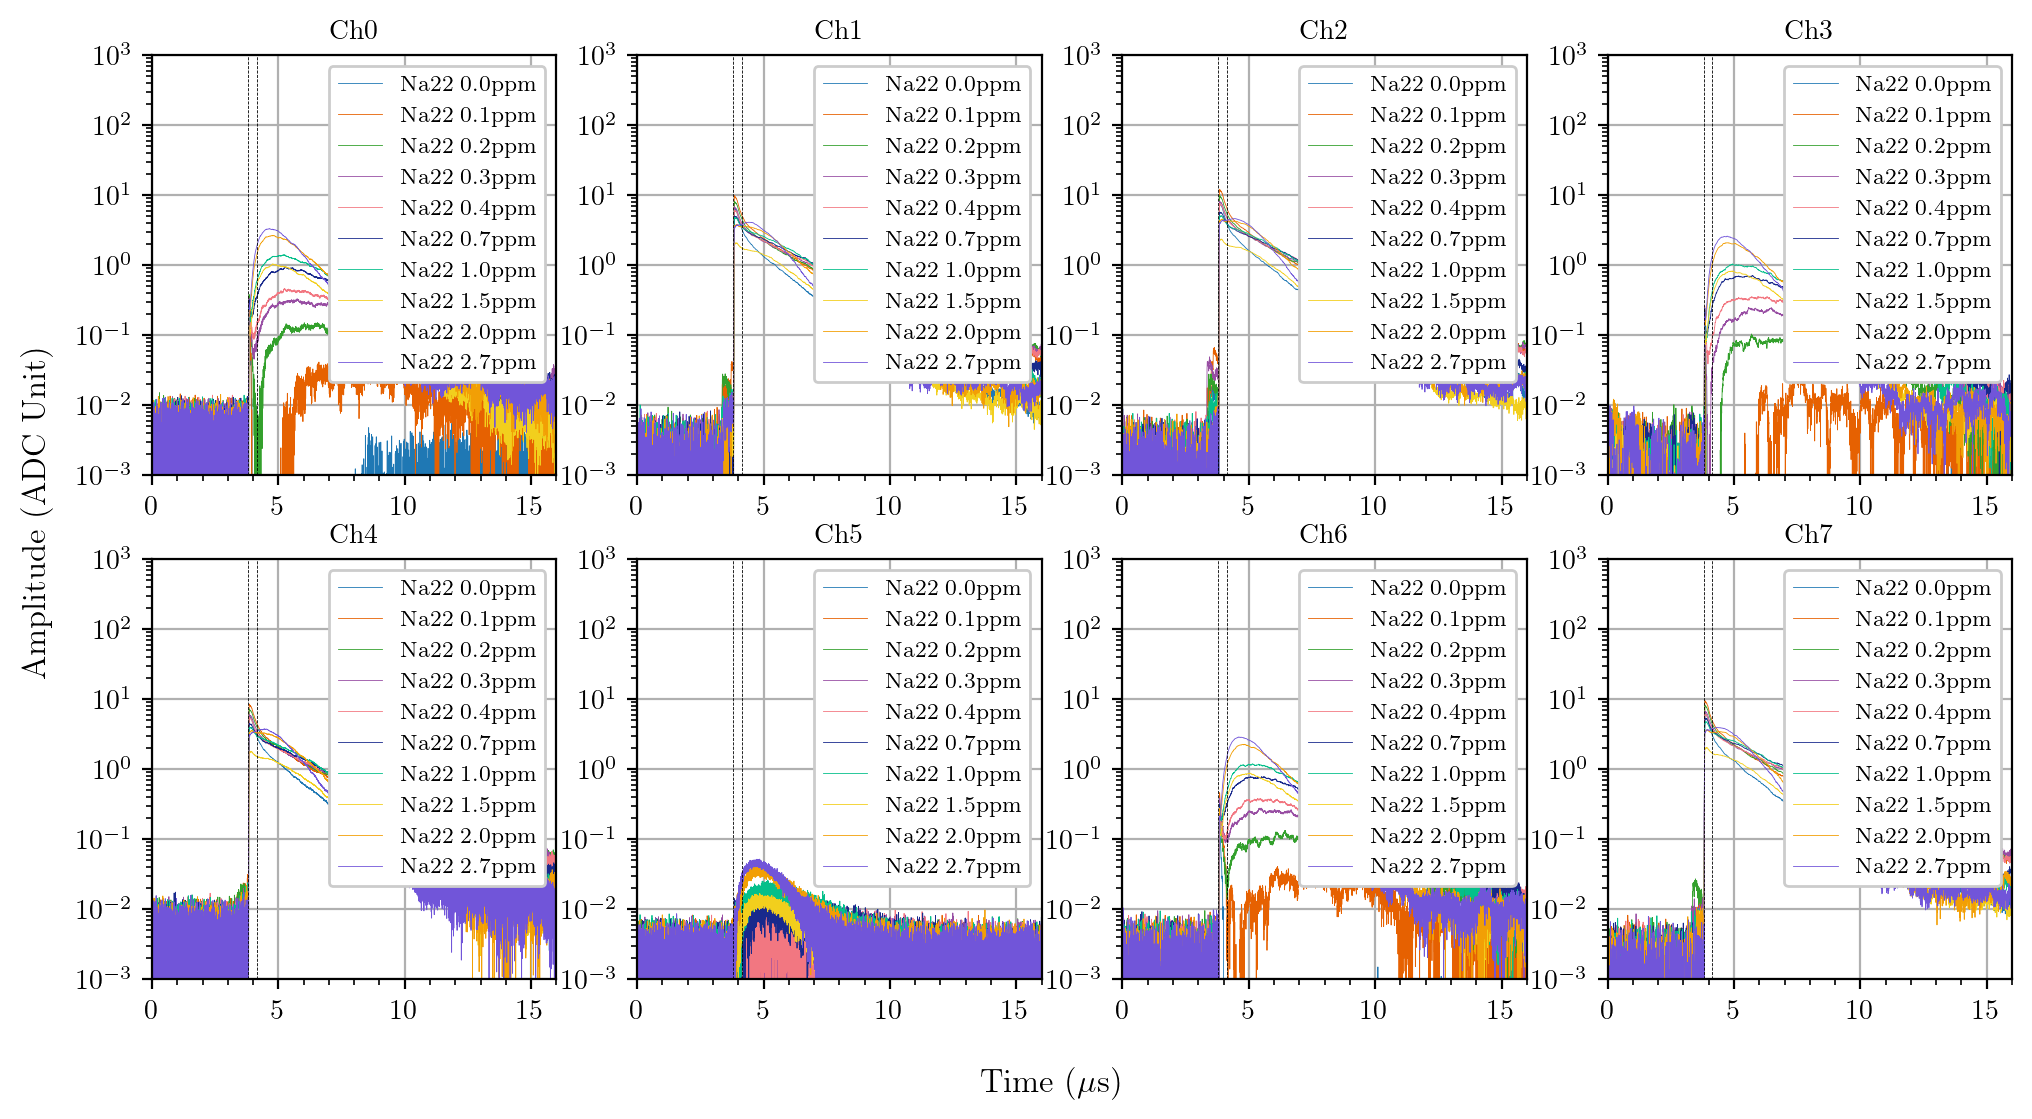

In [7]:
# Make plots for all datasets
# Average LAr scintillation waveform
t_trig = 3.84
ylims = (1e-3,1e3)
fig, axs = plt.subplots(2, 4, sharex=False, sharey=False)
fig.set_size_inches(12, 6)
for j, ch in enumerate(channels):
    for k, c in enumerate(cond):
        print(f'{c} ch{ch} {data_scint[k][ch]["n_scint_wfs"]:.0f} waveforms selected')
        axs[j//4, j%4].plot(
            data_scint[k][ch]['time'],
            data_scint[k][ch]['avg_scint_wf'],
            label=f'{c}', color=f'C{k}', linewidth=0.3)
    axs[j//4, j%4].legend(loc='upper right',fontsize=8)
    axs[j//4, j%4].set_xlim(0, 16)
    axs[j//4, j%4].set_ylim(*ylims)
    axs[j//4, j%4].set_yscale('log')
    axs[j//4, j%4].minorticks_on()
    axs[j//4, j%4].grid()
    axs[j//4, j%4].set_title(f'Ch{ch}')
    axs[j//4, j%4].plot([t_trig-10*0.004]*2, ylims, 'k--',linewidth=0.3)
    axs[j//4, j%4].plot([t_trig+0.3]*2, ylims, 'k--',linewidth=0.3)
fig.supxlabel(r'Time ($\mu$s)', y=0.01)
fig.supylabel(r'Amplitude (ADC Unit)', x=0.07)

## Processing

* Deconvolution channel-by-channel
* Sum over channels (WL and WW respectively)
* Down-sampling

In [8]:
# Deconvolution channel by channel
for i, f in enumerate(files):
    for j, ch in enumerate(channels):
        if data_scint[i][ch]['n_scint_wfs']>0 and data_spe[ch_old[ch]]['n_spe_wfs']>0:
            dt = data_spe[ch_old[ch]]['time'][1]-data_spe[ch_old[ch]]['time'][0]
            shift = np.array([np.exp(complex(0,-2*np.pi*freq*dt*int(t0_spe[ch_old[ch]]/dt))) for freq in data_spe[ch_old[ch]]['frequency']])
            data_scint[i][ch]['deconv'] = ifft(fft(data_scint[i][ch]['avg_scint_wf'])/data_spe[ch_old[ch]]['fft_spe_wf']*shift).real

In [9]:
# summation
for i,f in enumerate(files):
    data_scint[i][-1] = {'time': data_scint[i][0]['time'], 'sum_wf_nofs': np.zeros(data_scint[i][0]['time'].shape[0]),'sum_wf_fs': np.zeros(data_scint[i][0]['time'].shape[0])}
    for ch in channels_nofs:    
        if data_scint[i][ch]['n_scint_wfs']>0 and data_spe[ch]['n_spe_wfs']>0:
            data_scint[i][-1]['sum_wf_nofs'] += data_scint[i][ch]['deconv']
    for ch in channels_fs:
        if data_scint[i][ch]['n_scint_wfs']>0 and data_spe[ch]['n_spe_wfs']>0:
            data_scint[i][-1]['sum_wf_fs'] += data_scint[i][ch]['deconv']

In [10]:
# down-sampling
nsub = 4
for i,f in enumerate(files):
    data_scint[i][-1]['time_sub'], data_scint[i][-1]['sum_wf_sub_nofs'] = func.downsample(data_scint[i][-1]['time'],data_scint[i][-1]['sum_wf_nofs'],nsub)
    data_scint[i][-1]['time_sub'], data_scint[i][-1]['sum_wf_sub_fs'] = func.downsample(data_scint[i][-1]['time'],data_scint[i][-1]['sum_wf_fs'],nsub)

Text(0.01, 0.5, 'Amplitude (ADC Unit)')

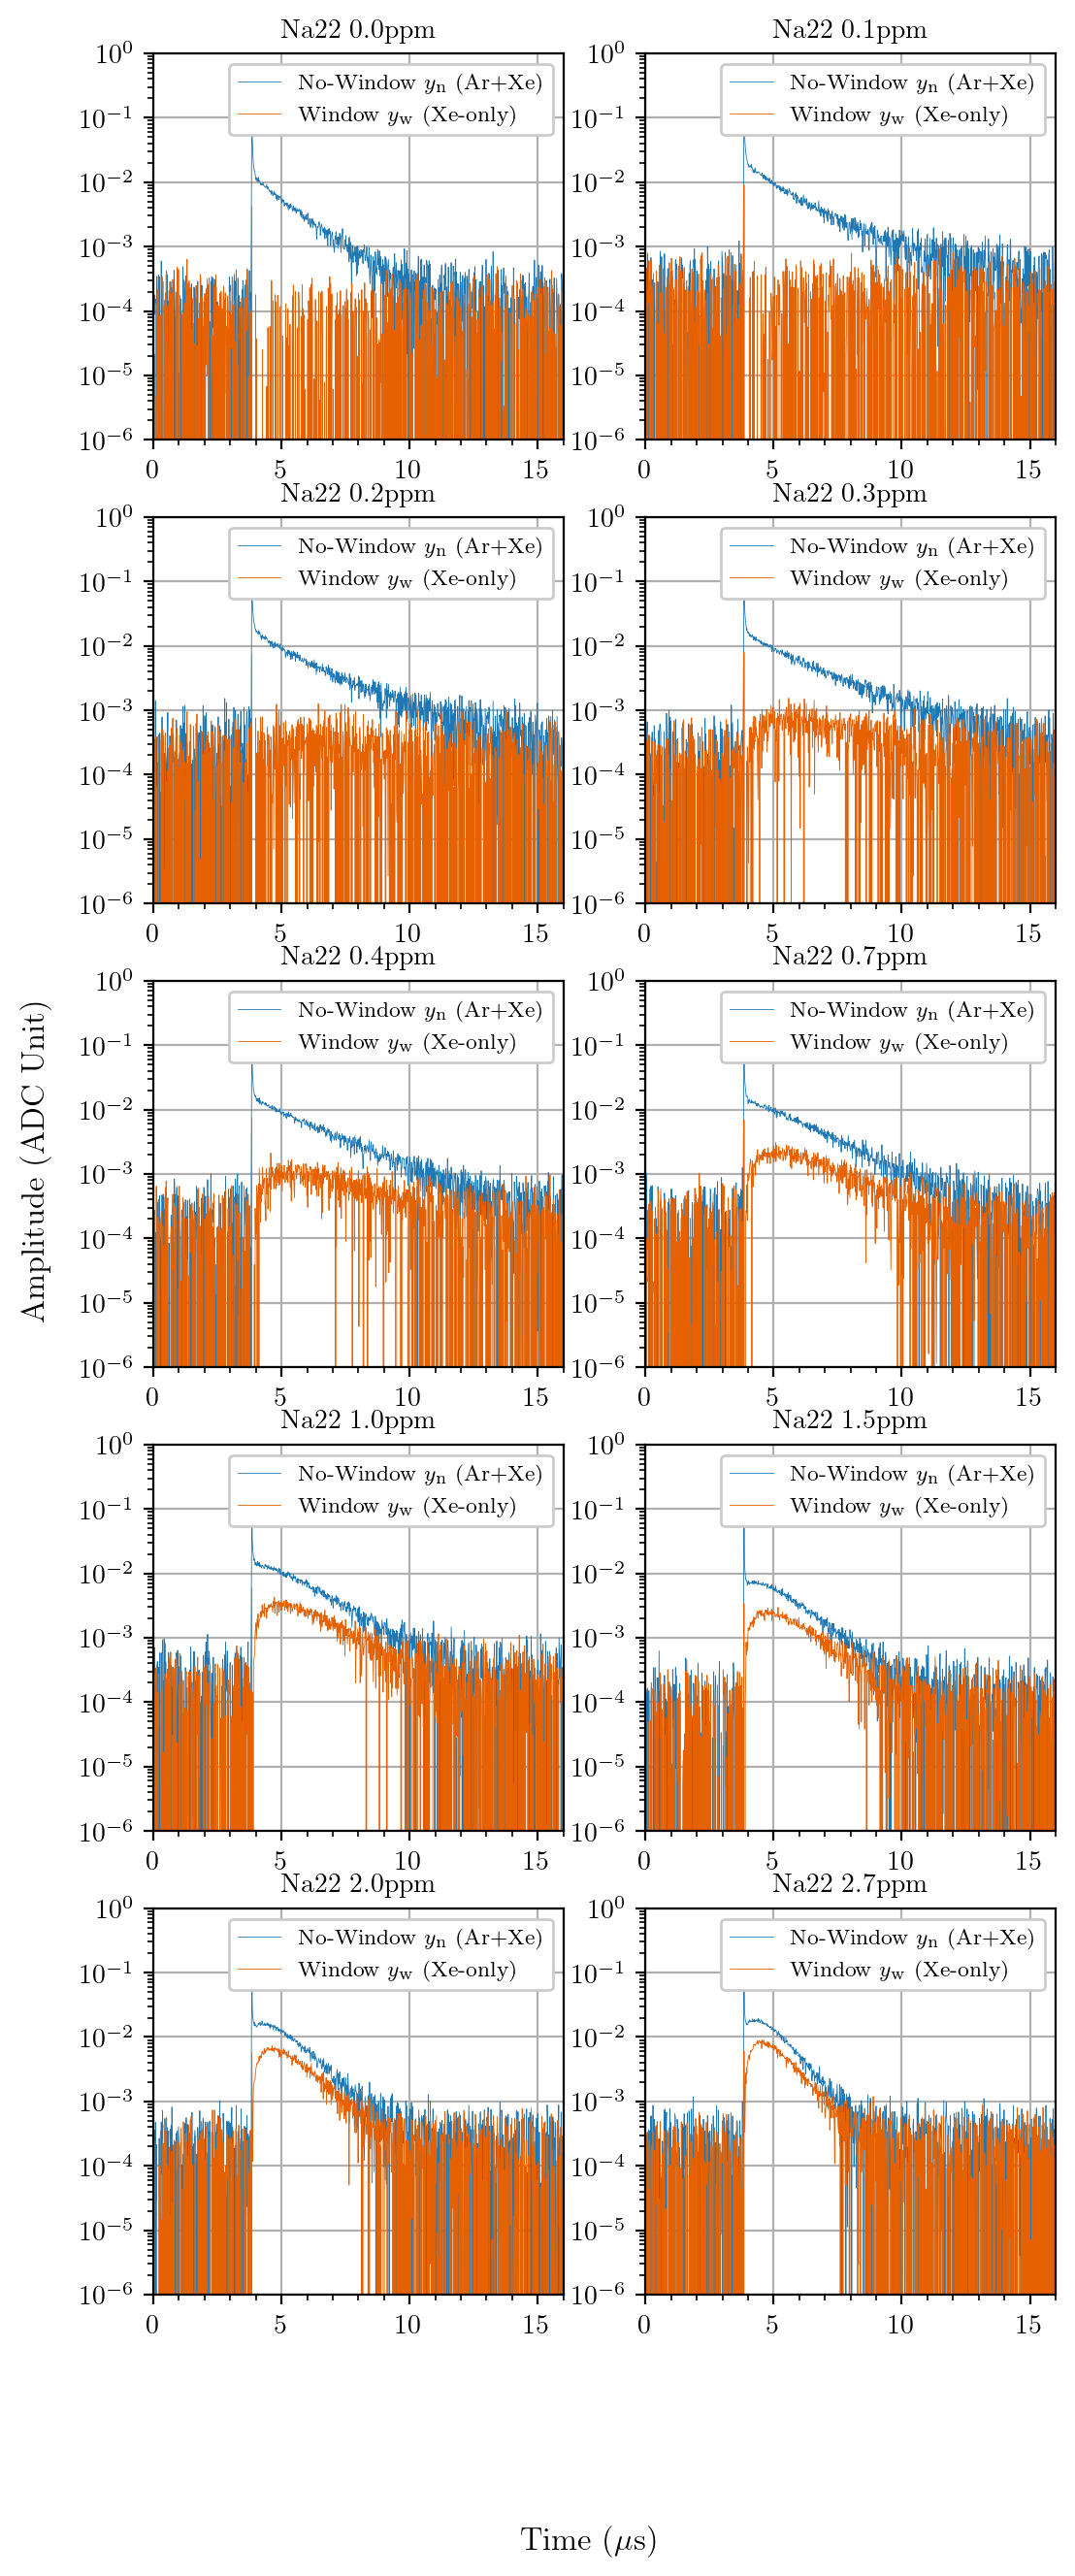

In [11]:
# Make plots for all datasets
# Summed scintillation waveform
fig, axs = plt.subplots(5, 2, sharex=False, sharey=False)
fig.set_size_inches(6, 15)
for i, c in enumerate(cond):
    axs[i//2,i%2].plot(
                data_scint[i][-1]['time_sub'],
                data_scint[i][-1]['sum_wf_sub_nofs'],
                linewidth=0.3,label=r'No-Window $y_{\rm n}$ (Ar+Xe)')
    axs[i//2,i%2].plot(
                data_scint[i][-1]['time_sub'],
                data_scint[i][-1]['sum_wf_sub_fs'],
                linewidth=0.3, label=r'Window $y_{\rm w}$ (Xe-only)')
    axs[i//2,i%2].set_xlim(0,16)
    axs[i//2,i%2].set_ylim(1e-6, 1e0)
    axs[i//2,i%2].set_yscale('log')
    axs[i//2,i%2].minorticks_on()
    axs[i//2,i%2].grid()
    axs[i//2,i%2].set_title(f'{c}')
    axs[i//2,i%2].legend(loc='upper right')
fig.supxlabel(r'Time ($\mu$s)', y=0.02)
fig.supylabel(r'Amplitude (ADC Unit)', x=0.01)

## WL + WW simultaneous fit

In [12]:
file_indices = np.arange(1,10) # exclude 0ppm data
t0 = 3.84
pars_all, perrs_all = [], []

for i in file_indices:
	# error estimate
	pretrg = 3.5 #us
	err_wl = np.std(data_scint[i][-1]['sum_wf_sub_nofs'][data_scint[i][-1]['time_sub']<pretrg])
	data_scint[i][-1]['sum_wf_sub_nofs_err'] = err_wl
	err_ww = np.std(data_scint[i][-1]['sum_wf_sub_fs'][data_scint[i][-1]['time_sub']<pretrg])
	data_scint[i][-1]['sum_wf_sub_fs_err'] = err_ww
	# set fit range
	fit_range = [4.2, 12] #us
	# fit_range = [4.5, 12] #us
	data_scint[i][-1]['fit_range_ww'] = fit_range
	data_scint[i][-1]['fit_range_wl'] = fit_range
	range_arr = (data_scint[i][-1]['time_sub']<fit_range[1]) & (data_scint[i][-1]['time_sub']>fit_range[0])
	# fit setup
	xdata = [
		data_scint[i][-1]['time_sub'][range_arr],
		data_scint[i][-1]['time_sub'][range_arr]
	]
	ydata = [
		data_scint[i][-1]['sum_wf_sub_nofs'][range_arr] + 0.015*data_scint[i][-1]['sum_wf_sub_fs'][range_arr],
		data_scint[i][-1]['sum_wf_sub_fs'][range_arr] + 0.015*data_scint[i][-1]['sum_wf_sub_nofs'][range_arr]
	]
	yerr = [
		err_wl*np.ones(np.sum(range_arr)), 
		err_ww*np.ones(np.sum(range_arr))
	]
	xdata = np.vstack([np.concatenate(xdata),np.concatenate([np.ones_like(xdata[j])*j for j in range(len(xdata))])]).T
	ydata = np.concatenate(ydata)
	yerr = np.concatenate(yerr)
	p0 = [
     	np.sum(data_scint[i][-1]['sum_wf_sub_nofs'][range_arr]),
		np.sum(data_scint[i][-1]['sum_wf_sub_fs'][range_arr]),
		np.sum(data_scint[i][-1]['sum_wf_sub_fs'][range_arr]),
		0.9,
  		2 if i<7 else 1.2
       ]
	# fit	
	popt, pcov = curve_fit(lambda x,*p: func.wl_ww_model(x,t0,*p), xdata, ydata, p0=p0, sigma=yerr, maxfev=10000)
	perr = np.array([func.error_distance(df=len(p0), sigma=1)*pcov[j,j]**0.5 for j in range(len(popt))])
	if popt[3]>popt[4]:
		popt[3],popt[4] = popt[3],popt[4]
		perr[3],perr[4] = perr[3],perr[4]
	print(f'{i} {cond[i]} {p0} {popt} {perr}')
	pars_all.append(popt)
	perrs_all.append(perr)

1 Na22 0.1ppm [1.7869676307144353, 0.014027674873644673, 0.014027674873644673, 0.9, 2] [1.52298416 0.78891821 0.04911819 1.21060013 3.47221316] [0.24996908 0.21502698 0.02176694 0.22939022 1.06941002]
2 Na22 0.2ppm [1.8165302133935732, 0.09156836631985216, 0.09156836631985216, 0.9, 2] [1.17981241 1.12333611 0.13405413 1.05848481 3.07882915] [0.2372225  0.22876023 0.02183828 0.24207895 0.40814149]
3 Na22 0.3ppm [1.8649234709190257, 0.20826394738623694, 0.20826394738623694, 0.9, 2] [0.97884185 1.34965388 0.26354318 0.95937181 2.91810219] [0.1391912  0.14485187 0.01905634 0.15260917 0.16227797]
4 Na22 0.4ppm [1.8859244727539892, 0.2873664952653699, 0.2873664952653699, 0.9, 2] [0.86503435 1.45922312 0.34543108 0.89169638 2.71589778] [0.1113309  0.12194803 0.0177056  0.1248946  0.12225482]
5 Na22 0.7ppm [1.90114464046733, 0.5024626678072193, 0.5024626678072193, 0.9, 2] [0.67724204 1.60614275 0.56990379 0.76899326 2.25780906] [0.07757208 0.08743321 0.01790092 0.08518186 0.08753866]
6 Na22 1.

Text(0.5, 1.0, '0 ppm')

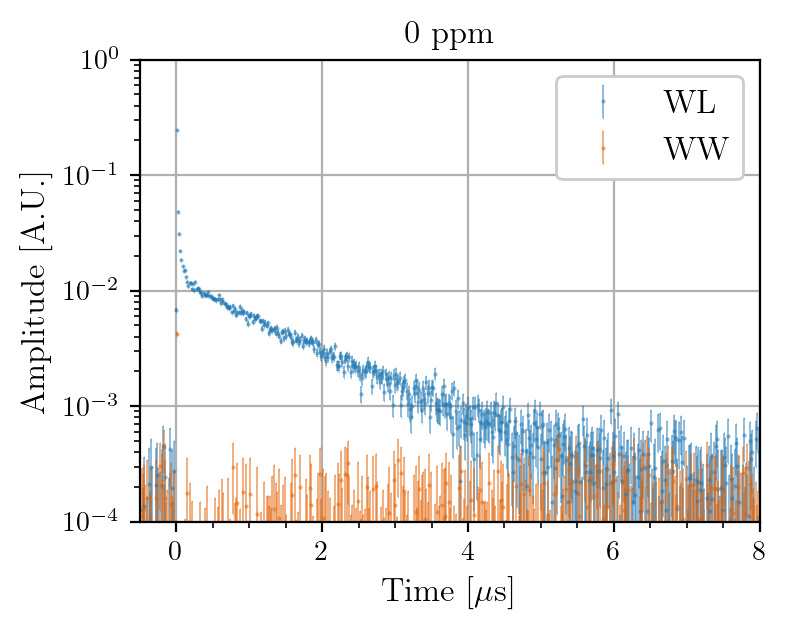

In [13]:
plt.figure(0)
i = 0
plt.errorbar(
	data_scint[i][-1]['time_sub']-t0,
	data_scint[i][-1]['sum_wf_sub_nofs'],
	yerr=np.std(data_scint[i][-1]['sum_wf_sub_nofs'][data_scint[i][-1]['time_sub']<0.9*t0]),
	fmt='.', markersize=1, linewidth=0.7, capsize=0.1, label='WL', alpha=0.5)

plt.errorbar(
	data_scint[i][-1]['time_sub']-t0,
	data_scint[i][-1]['sum_wf_sub_fs'],
	yerr=np.std(data_scint[i][-1]['sum_wf_sub_fs'][data_scint[i][-1]['time_sub']<0.9*t0]),
	fmt='.', markersize=1, linewidth=0.7, capsize=0.1, label='WW', alpha=0.5)

plt.xlim(-0.5,8)
plt.ylim(1e-4,1)
plt.yscale('log')
plt.grid()
plt.minorticks_on()
plt.legend(loc='upper right',fontsize=12)
plt.xlabel(r'Time [$\rm \mu s$]',fontsize=12)
plt.ylabel(r'Amplitude [A.U.]',fontsize=12)
plt.title(f'{conc[i]:.2g} ppm',fontsize=12)

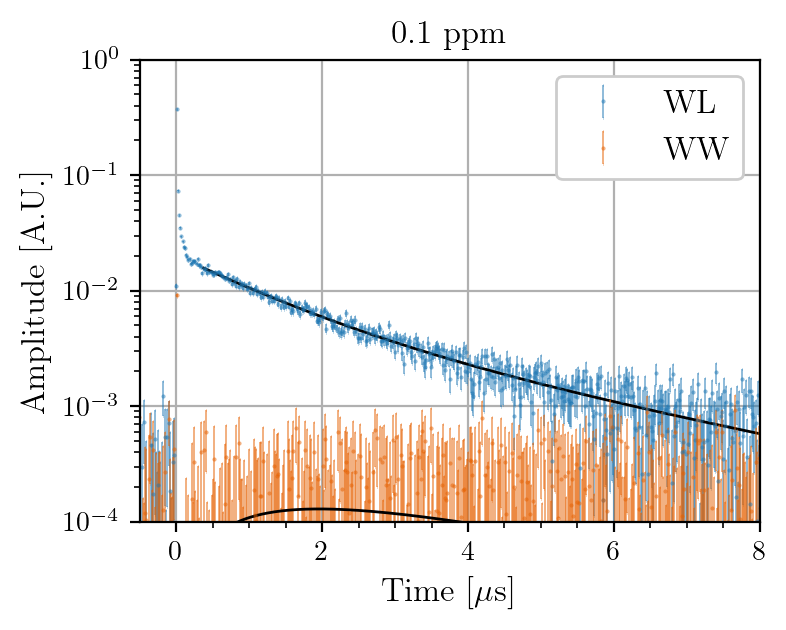

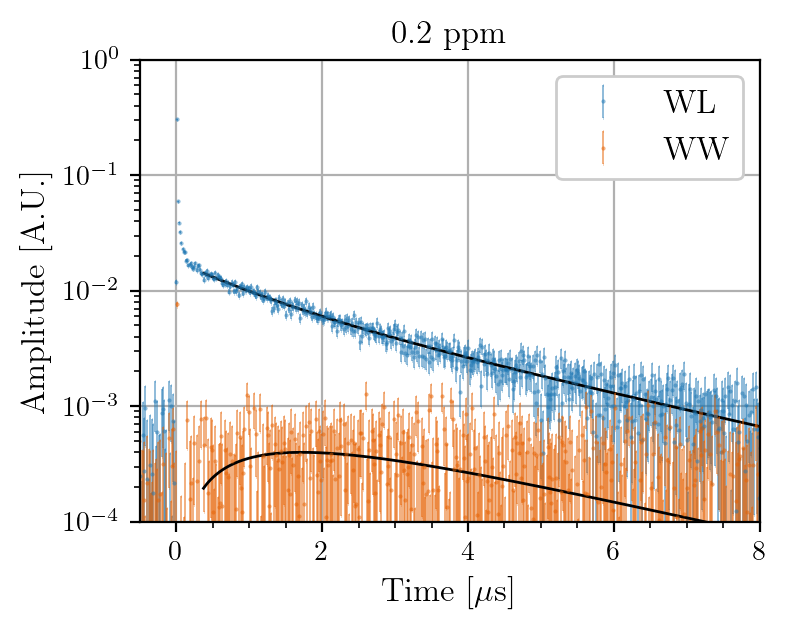

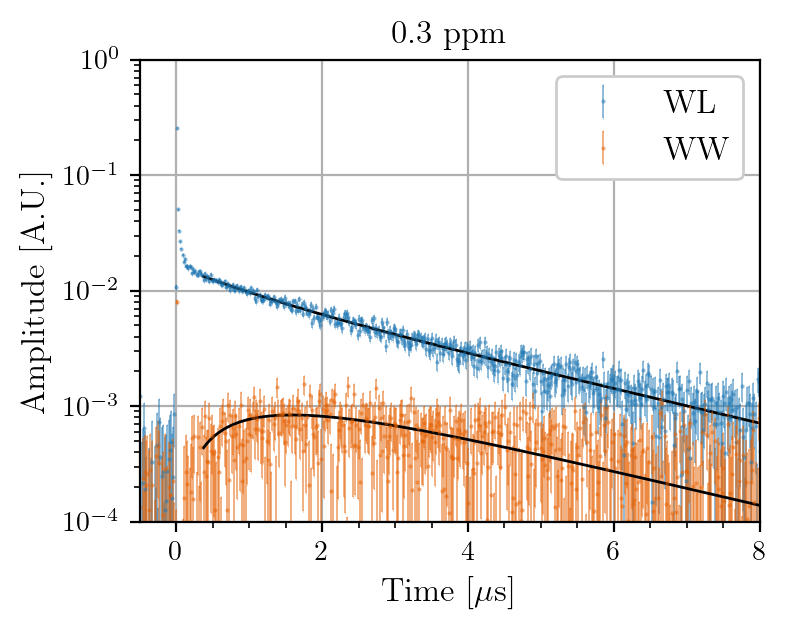

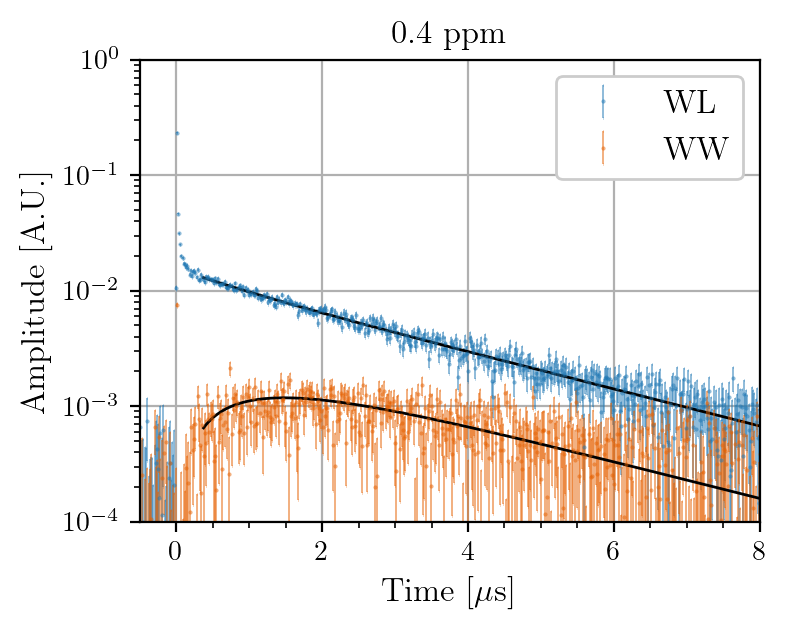

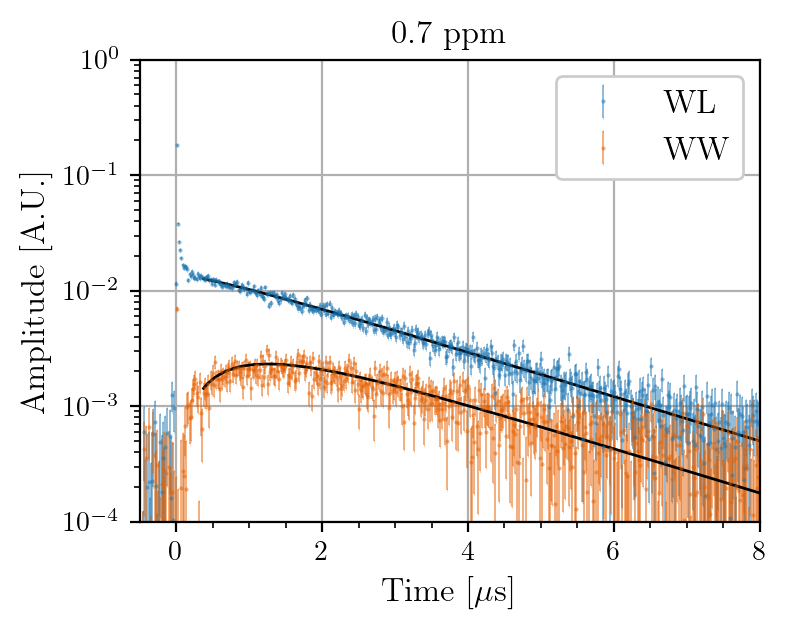

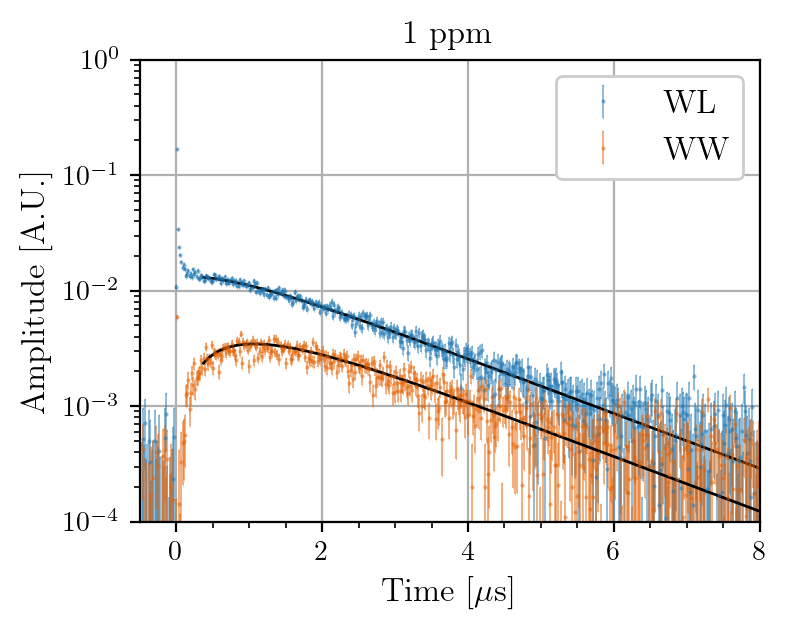

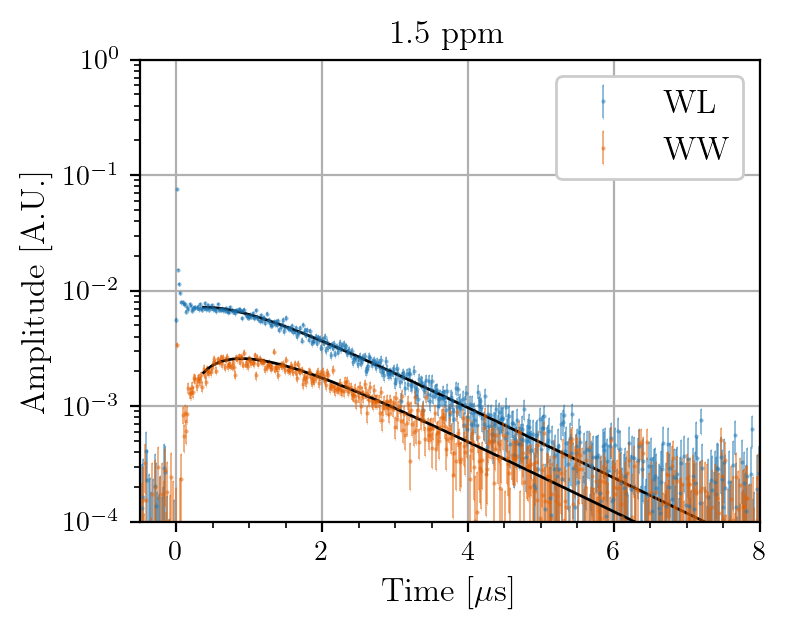

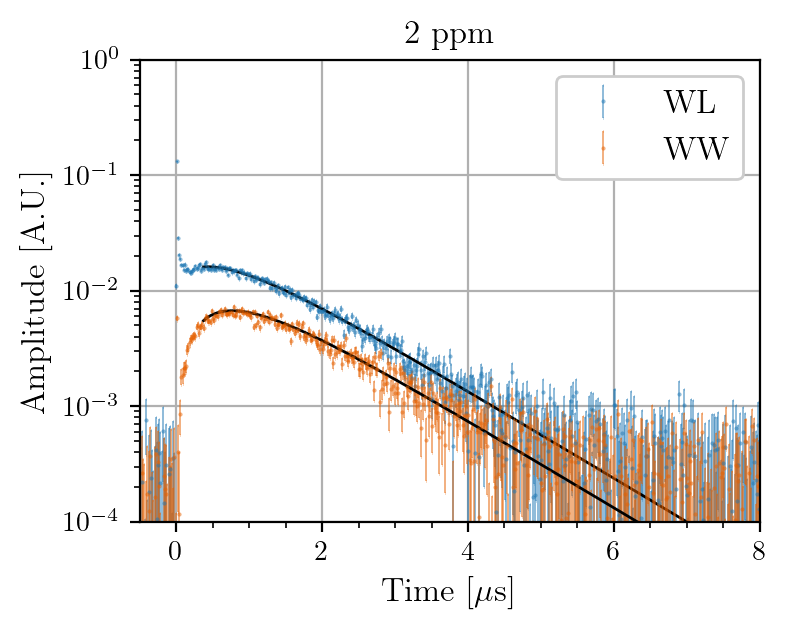

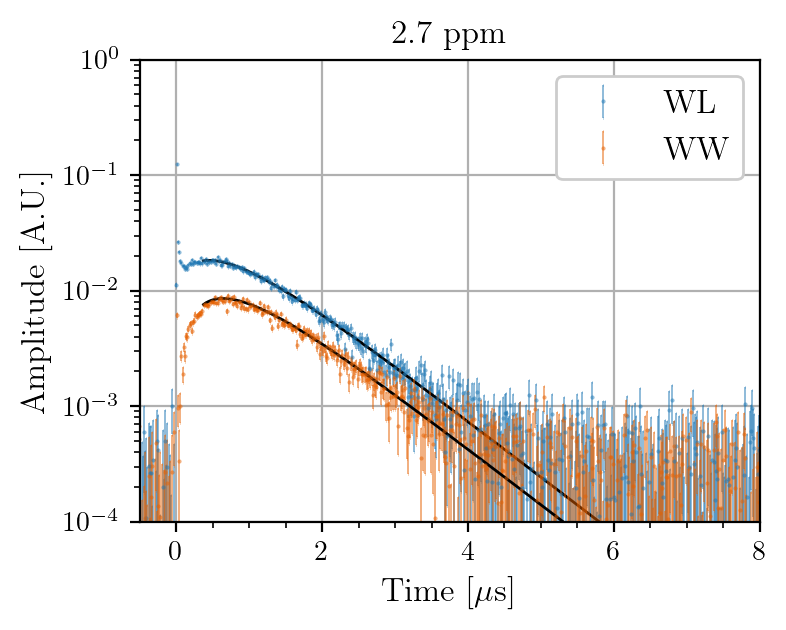

In [14]:
for i_fit in range(len(file_indices)):
	plt.figure(i_fit)
	i = file_indices[i_fit]
	plt.errorbar(
		data_scint[i][-1]['time_sub']-t0,
		data_scint[i][-1]['sum_wf_sub_nofs'],
		yerr=data_scint[i][-1]['sum_wf_sub_nofs_err'],
		fmt='.', markersize=1, linewidth=0.7, capsize=0.1, label='WL', alpha=0.5)
	mask = (data_scint[i][-1]['time_sub']>data_scint[i][-1]['fit_range_wl'][0]) & (data_scint[i][-1]['time_sub']<data_scint[i][-1]['fit_range_wl'][1])
	plt.plot(data_scint[i][-1]['time_sub'][mask]-t0, 
		func.wl_model(data_scint[i][-1]['time_sub'][mask]-t0,pars_all[i_fit][0],pars_all[i_fit][1],pars_all[i_fit][3],pars_all[i_fit][4]),
		color='k', linestyle='-', linewidth=1)
 
	plt.errorbar(
		data_scint[i][-1]['time_sub']-t0,
		data_scint[i][-1]['sum_wf_sub_fs'],
		yerr=data_scint[i][-1]['sum_wf_sub_fs_err'],
		fmt='.', markersize=1, linewidth=0.7, capsize=0.1, label='WW', alpha=0.5)
	mask = (data_scint[i][-1]['time_sub']>data_scint[i][-1]['fit_range_ww'][0]) & (data_scint[i][-1]['time_sub']<data_scint[i][-1]['fit_range_ww'][1])
	plt.plot(data_scint[i][-1]['time_sub'][mask]-t0, 
		func.ww_model(data_scint[i][-1]['time_sub'][mask]-t0,pars_all[i_fit][2],pars_all[i_fit][3],pars_all[i_fit][4]),
		color='k', linestyle='-', linewidth=1)
 
	plt.xlim(-0.5,8)
	plt.ylim(1e-4,1)
	plt.yscale('log')
	plt.grid()
	plt.minorticks_on()
	plt.legend(loc='upper right',fontsize=12)
	plt.xlabel(r'Time [$\rm \mu s$]',fontsize=12)
	plt.ylabel(r'Amplitude [A.U.]',fontsize=12)
	plt.title(f'{conc[i]:.2g} ppm',fontsize=12)

## Rate Constant $k$ and ArXe lifetime $\tau_{ArXe}$

Compare Liq. #6 and Liq. #7

In [15]:
df = pd.read_hdf('/home/as111/sipm-analysis/tau_arxe_liq6.h5',key='tau_arxe_liq6')
df

,conc,tau_inv,tau_inv_err
0,2.7,0.994751,0.104175
1,5.0,1.613201,0.132068
2,10.0,2.963616,0.252846
3,20.0,5.460437,0.592910
4,40.0,8.204542,0.469400


Run 1 reaction rate constant k=0.26 $\pm$0.01 $\rm \mu s^{-1} ppm^{-1}$
Run 1 ArXe lifetime $\tau_{ArXe}=$ 3.45\pm0.43 $\rm \mu s
Run 2 reaction rate constant k=0.31 $\pm$0.01 $\rm \mu s^{-1} ppm^{-1}$
Run 2 ArXe lifetime $\tau_{ArXe}=$ 4.15\pm0.18 $\rm \mu s


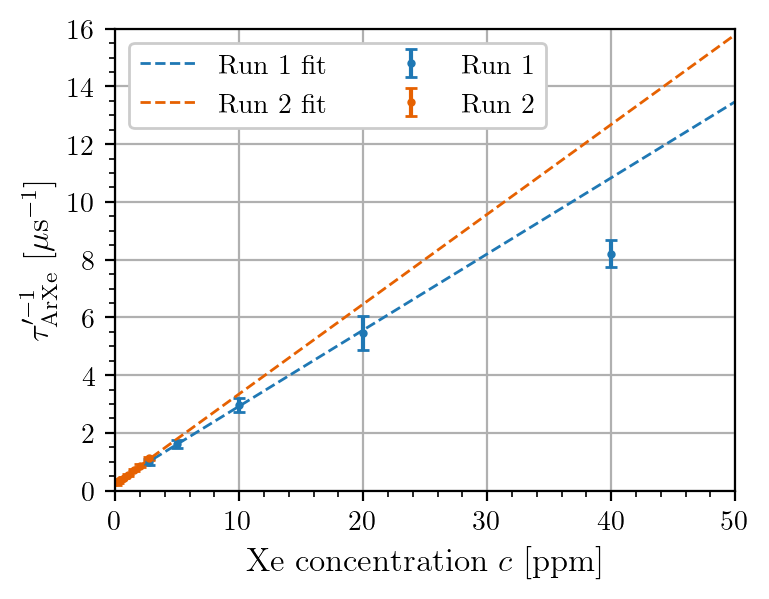

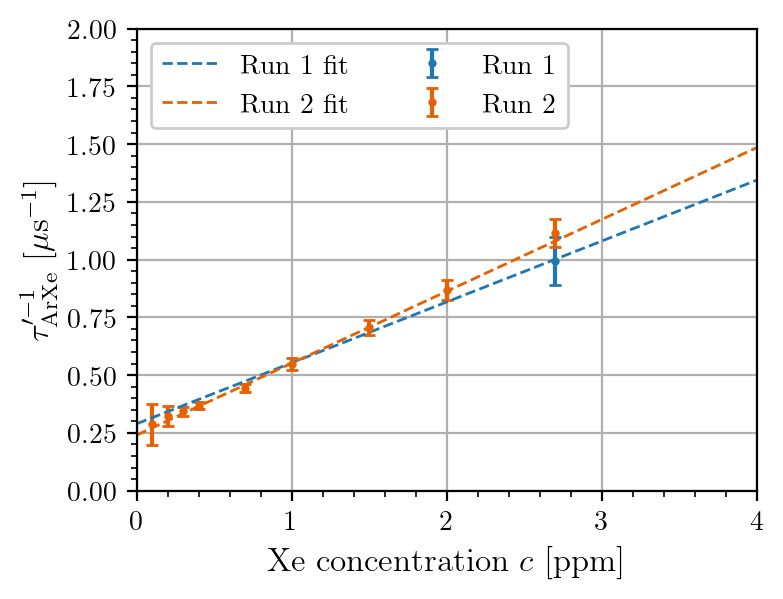

In [16]:
# Run 1 fits
popt1,pcov1 = curve_fit(lambda x,a,b: a*x+b, df['conc'][:-1], df['tau_inv'][:-1], sigma=df['tau_inv_err'][:-1])
k_rate1, k_rate1_err = popt1[0], func.error_distance(df=2,sigma=1)*pcov1[0,0]**0.5
tau_arxe0_1, tau_arxe0_1_err = 1/popt1[1], func.error_distance(df=2,sigma=1)*pcov1[1,1]**0.5/popt1[1]**2
print(f'Run 1 reaction rate constant k={k_rate1:.2f} ' + r'$\pm$' + f'{k_rate1_err:.2f} ' + r'$\rm \mu s^{-1} ppm^{-1}$')
print(r'Run 1 ArXe lifetime $\tau_{ArXe}=$ ' + f'{tau_arxe0_1:.2f}' + r'\pm' + f'{tau_arxe0_1_err:.2f} ' + r'$\rm \mu s')

# Run 2 fits
tau_inv_2 = [1/np.abs(p[4]) for p in pars_all]
tau_inv_2_err = [e[4]/p[4]**2 for e,p in zip(perrs_all,pars_all)]
popt2,pcov2 = curve_fit(lambda x,a,b: a*x+b, conc[file_indices], tau_inv_2, sigma=tau_inv_2_err)
k_rate2, k_rate2_err = popt2[0], func.error_distance(df=2,sigma=1)*pcov2[0,0]**0.5
tau_arxe0_2, tau_arxe0_2_err = 1/popt2[1], func.error_distance(df=2,sigma=1)*pcov2[1,1]**0.5/popt2[1]**2
print(f'Run 2 reaction rate constant k={k_rate2:.2f} ' + r'$\pm$' + f'{k_rate2_err:.2f} ' + r'$\rm \mu s^{-1} ppm^{-1}$')
print(r'Run 2 ArXe lifetime $\tau_{ArXe}=$ ' + f'{tau_arxe0_2:.2f}' + r'\pm' + f'{tau_arxe0_2_err:.2f} ' + r'$\rm \mu s')


# Large scale
plt.figure(0)
plt.errorbar(df['conc'], df['tau_inv'], yerr=df['tau_inv_err'], label='Run 1',
             color='C0',linestyle='', linewidth=1.5, fmt='o', markersize=2, capsize=2)
plt.errorbar(conc[file_indices], tau_inv_2, yerr=tau_inv_2_err, label='Run 2',
             color='C1',linestyle='', linewidth=1.5, fmt='o', markersize=2, capsize=2)
xarr = np.linspace(0,50,100)
plt.plot(xarr, popt1[0]*xarr+popt1[1], 'C0--', label='Run 1 fit', lw=1)
plt.plot(xarr, popt2[0]*xarr+popt2[1], 'C1--', label='Run 2 fit', lw=1)
plt.xlim(0,50)
plt.ylim(0,16)
plt.grid()
plt.minorticks_on()
plt.xlabel(r'Xe concentration $c$ [ppm]',fontsize=12)
plt.ylabel(r'$\tau_{\rm ArXe}^{\prime -1}$ [$\rm \mu s^{-1}$]',fontsize=12)
plt.legend(ncol=2,fontsize=10)

# small scale
plt.figure(1)
plt.errorbar(df['conc'], df['tau_inv'], yerr=df['tau_inv_err'], label='Run 1',
             color='C0',linestyle='', linewidth=1.5, fmt='o', markersize=2, capsize=2)
plt.errorbar(conc[file_indices], tau_inv_2, yerr=tau_inv_2_err, label='Run 2',
             color='C1',linestyle='', linewidth=1.5, fmt='o', markersize=2, capsize=2)
xarr = np.linspace(0,50,100)
plt.plot(xarr, popt1[0]*xarr+popt1[1], 'C0--', label='Run 1 fit', lw=1)
plt.plot(xarr, popt2[0]*xarr+popt2[1], 'C1--', label='Run 2 fit', lw=1)
plt.xlim(0,4)
plt.ylim(0,2)
plt.grid()
plt.minorticks_on()
plt.xlabel(r'Xe concentration $c$ [ppm]',fontsize=12)
plt.ylabel(r'$\tau_{\rm ArXe}^{\prime -1}$ [$\rm \mu s^{-1}$]',fontsize=12)
plt.legend(ncol=2,fontsize=10)



In [17]:
# save data points
df = pd.DataFrame({
	'conc': conc[file_indices],
	'tau_inv': tau_inv_2,
	'tau_inv_err': tau_inv_2_err,
})
df.to_hdf('/home/as111/sipm-analysis/tau_arxe_liq7.h5',key='tau_arxe_liq7')

## Relative Amplitude analysis

$$\eta = \frac{A_1}{A^{WL}_0 \tau'_{ArXe}}$$

- $A^{WL}_0$: amplitude of single-exponential component for WL
- $a_1$: amplitude of double-exponential component (WL or WW)
- $\tau'_{ArXe}$: quenched ArXe lifetime

In the limit of $c\rightarrow 0$,

$$\eta_{WL} \rightarrow c^1$$

$$\eta_{WW} \rightarrow c^2$$

Text(0, 0.5, '$\\eta/c$ [$\\rm \\mu s^{-1} ppm^{-1}$]')

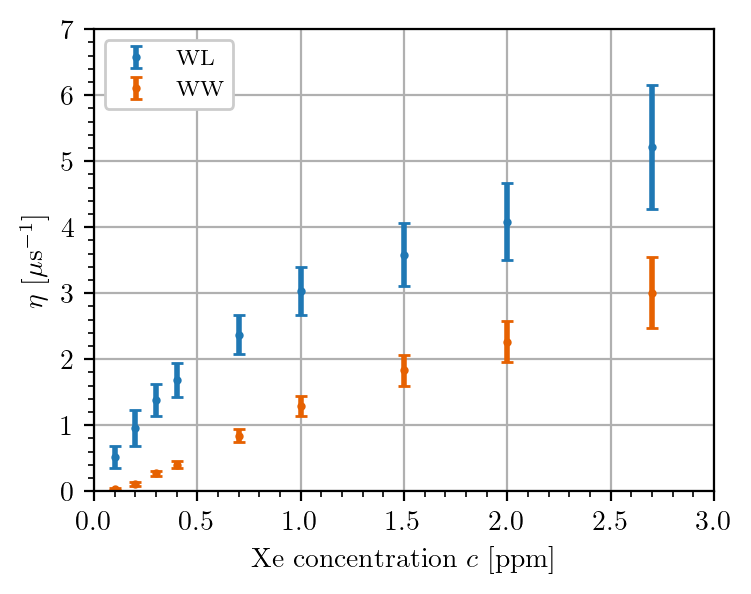

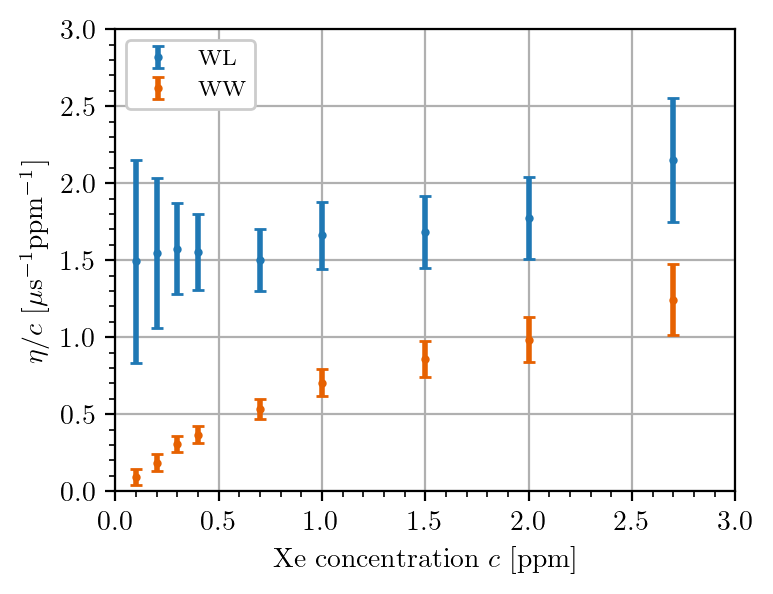

In [18]:
plt.figure(0)
plt.errorbar(
    np.array(conc[file_indices]), 
    [p[1]/p[0] for p in pars_all], 
    [(p[1]/p[0])*( (e[1]/p[1])**2 + (e[0]/p[0])**2 )**0.5 for p,e in zip(pars_all,perrs_all)],
    label='WL',linestyle='', linewidth=2, fmt='o', markersize=2, capsize=2)
plt.errorbar(
    np.array(conc[file_indices]), 
    [p[2]/p[0] for p in pars_all],
    [(p[2]/p[0])*( (e[2]/p[2])**2 + (e[0]/p[0])**2 )**0.5 for p,e in zip(pars_all,perrs_all)],
    label='WW',linestyle='', linewidth=2, fmt='o', markersize=2, capsize=2)
plt.grid()
plt.minorticks_on()
plt.legend()
plt.xlabel(r'Xe concentration $c$ [ppm]')
plt.ylabel(r'$\eta$ [$\rm \mu s^{-1}$]')

plt.figure(1)
plt.errorbar(
    np.array(conc[file_indices]), 
    [p[1]/p[0]/p[4]/c for p,c in zip(pars_all,conc[file_indices])], 
    [p[1]/p[0]/p[4]/c * ( (e[1]/p[1])**2 + (e[0]/p[0])**2 + (e[4]/p[4])**2 )**0.5 for p,e,c in zip(pars_all,perrs_all,conc[file_indices])], 
    label='WL',linestyle='', linewidth=2, fmt='o', markersize=2, capsize=2)
plt.errorbar(
    np.array(conc[file_indices]), 
    [p[2]/p[0]/p[4]/c for p,c in zip(pars_all,conc[file_indices])], 
    [p[2]/p[0]/p[4]/c * ( (e[2]/p[2])**2 + (e[0]/p[0])**2 + (e[4]/p[4])**2 )**0.5 for p,e,c in zip(pars_all,perrs_all,conc[file_indices])], 
    label='WW',linestyle='', linewidth=2, fmt='o', markersize=2, capsize=2)
plt.grid()
plt.minorticks_on()
plt.legend()
plt.xlabel(r'Xe concentration $c$ [ppm]')
plt.ylabel(r'$\eta/c$ [$\rm \mu s^{-1} ppm^{-1}$]')

# Estimate Xe concentration in each Na-22 monitoring dataset

## Load Data

In [19]:
S_PER_HR = 3600

dt_xe = [
	datetime(2024,5,9,14,30,0),
	datetime(2024,5,16,10,44,0),
	datetime(2024,5,16,18,24,0),
	datetime(2024,5,20,16,35,0),
	datetime(2024,5,22,14,48,0),
	datetime(2024,5,23,16,30,0),
	datetime(2024,5,24,16,54,0),
	datetime(2024,5,28,15,26,0),
	datetime(2024,5,29,14,35,0)
]
hr_dt_xe = [(dt_xe[i]-dt_xe[0]).total_seconds()/S_PER_HR for i in range(1,len(dt_xe))]

for i,t in enumerate(dt_xe):
    print(f'Xenon injection #{i+1} at {t} ' + (f'({hr_dt_xe[i-1]:.0f} hr after #1)' if i>0 else ''))

Xenon injection #1 at 2024-05-09 14:30:00 
Xenon injection #2 at 2024-05-16 10:44:00 (164 hr after #1)
Xenon injection #3 at 2024-05-16 18:24:00 (172 hr after #1)
Xenon injection #4 at 2024-05-20 16:35:00 (266 hr after #1)
Xenon injection #5 at 2024-05-22 14:48:00 (312 hr after #1)
Xenon injection #6 at 2024-05-23 16:30:00 (338 hr after #1)
Xenon injection #7 at 2024-05-24 16:54:00 (362 hr after #1)
Xenon injection #8 at 2024-05-28 15:26:00 (457 hr after #1)
Xenon injection #9 at 2024-05-29 14:35:00 (480 hr after #1)


In [20]:
# Xe injection monitoring
path = "/scratch/gpfs/GALBIATI/as111/results/"
dates = ['2024-05-09',	# injection #1
         '2024-05-16',	# injection #2 #3
         '2024-05-20',	# injection #4
         '2024-05-22',	# injection #5
         '2024-05-23',	# injection #6
         '2024-05-24',	# injection #7
         '2024-05-28',	# injection #8
         '2024-05-29'	# injection #9
        ]
files = []
for d in dates:
    files.extend(glob.glob(f"{path}{d}/*cond_monitor*scintillation_waveform_liq7.h5"))
for i,f in enumerate(files):
    files[i] = [files[i]]
print(files)
print(len(files))

[['/scratch/gpfs/GALBIATI/as111/results/2024-05-09/2024-05-09_volt_98_light_scintillation_cond_monitor_source_co60_xenon_1_run28_scintillation_waveform_liq7.h5'], ['/scratch/gpfs/GALBIATI/as111/results/2024-05-09/2024-05-09_volt_98_light_scintillation_cond_monitor_source_co60_xenon_1_run10_scintillation_waveform_liq7.h5'], ['/scratch/gpfs/GALBIATI/as111/results/2024-05-09/2024-05-09_volt_98_light_scintillation_cond_monitor_source_co60_xenon_1_run26_scintillation_waveform_liq7.h5'], ['/scratch/gpfs/GALBIATI/as111/results/2024-05-09/2024-05-09_volt_98_light_scintillation_cond_monitor_source_co60_xenon_1_run0_scintillation_waveform_liq7.h5'], ['/scratch/gpfs/GALBIATI/as111/results/2024-05-09/2024-05-09_volt_98_light_scintillation_cond_monitor_source_co60_xenon_1_run2_scintillation_waveform_liq7.h5'], ['/scratch/gpfs/GALBIATI/as111/results/2024-05-09/2024-05-09_volt_98_light_scintillation_cond_monitor_source_co60_xenon_1_run4_scintillation_waveform_liq7.h5'], ['/scratch/gpfs/GALBIATI/as111

In [21]:
# data folder
data_scint = {}
date_time = {}
channels = np.arange(8)
channels_nofs = [1,2,4,7] 
channels_fs = [0,3,6]
ch_old = [0,5,6,3,4,1,2,7] # map to channels in liq5 calibration data
volt = 98
for i,fs in enumerate(files):
    data_scint[i] = {}
    for j,f in enumerate(fs):
        df = pd.read_hdf(f, key=f'{volt}/-1')
        if j==0:
            date_time[i] = datetime(*np.array(df['start_datetime'][:6]).astype(int))
        for ch in channels:
            if j==0:
                data_scint[i][ch] = {'n_scint_wfs':0, 'avg_scint_wf':np.zeros(0), 'time':np.zeros(0)}
            df = pd.read_hdf(f, key=f'{volt}/{ch}')
            data_scint[i][ch]['n_scint_wfs'] += np.array(df['n_scint_wfs'])[0]
            if data_scint[i][ch]['time'].shape[0]==0:
                data_scint[i][ch]['time'] = np.array(df['time'].dropna())
            if data_scint[i][ch]['avg_scint_wf'].shape[0]==0:
                data_scint[i][ch]['avg_scint_wf'] = np.array(df['avg_scint_wf'].dropna())*np.array(df['n_scint_wfs'])[0]
            else:
                data_scint[i][ch]['avg_scint_wf'] += np.array(df['avg_scint_wf'].dropna())*np.array(df['n_scint_wfs'])[0]
            df = None
            data_scint[i][ch]['avg_scint_wf'] /= data_scint[i][ch]['n_scint_wfs']
# sort according to date time
args = np.array(list(date_time.values())).argsort()
files = [files[i] for i in args]
data_scint = [data_scint[i] for i in args]
date_time = [date_time[i] for i in args]
hr_from_inject = [(dt-dt_xe[0]).total_seconds()/S_PER_HR for dt in date_time]

## Processing

* Deconvolution channel-by-channel
* Sum over channels (WL and WW respectively)
* Down-sampling

In [22]:
# Deconvolution channel by channel
for i, f in enumerate(files):
    for j, ch in enumerate(channels):
        if data_scint[i][ch]['n_scint_wfs']>0 and data_spe[ch_old[ch]]['n_spe_wfs']>0:
            dt = data_spe[ch_old[ch]]['time'][1]-data_spe[ch_old[ch]]['time'][0]
            shift = np.array([np.exp(complex(0,-2*np.pi*freq*dt*int(t0_spe[ch_old[ch]]/dt))) for freq in data_spe[ch_old[ch]]['frequency']])
            data_scint[i][ch]['deconv'] = ifft(fft(data_scint[i][ch]['avg_scint_wf'])/data_spe[ch_old[ch]]['fft_spe_wf']*shift).real

In [23]:
# summation
for i,f in enumerate(files):
    data_scint[i][-1] = {'time': data_scint[i][0]['time'], 'sum_wf_nofs': np.zeros(data_scint[i][0]['time'].shape[0]),'sum_wf_fs': np.zeros(data_scint[i][0]['time'].shape[0])}
    for ch in channels_nofs:    
        if data_scint[i][ch]['n_scint_wfs']>0 and data_spe[ch]['n_spe_wfs']>0:
            data_scint[i][-1]['sum_wf_nofs'] += data_scint[i][ch]['deconv']
    for ch in channels_fs:
        if data_scint[i][ch]['n_scint_wfs']>0 and data_spe[ch]['n_spe_wfs']>0:
            data_scint[i][-1]['sum_wf_fs'] += data_scint[i][ch]['deconv']

In [24]:
# subsampling
nsub = 4
for i,f in enumerate(files):
    data_scint[i][-1]['time_sub'], data_scint[i][-1]['sum_wf_sub_nofs'] = func.downsample(data_scint[i][-1]['time'],data_scint[i][-1]['sum_wf_nofs'],nsub)
    data_scint[i][-1]['time_sub'], data_scint[i][-1]['sum_wf_sub_fs'] = func.downsample(data_scint[i][-1]['time'],data_scint[i][-1]['sum_wf_fs'],nsub)

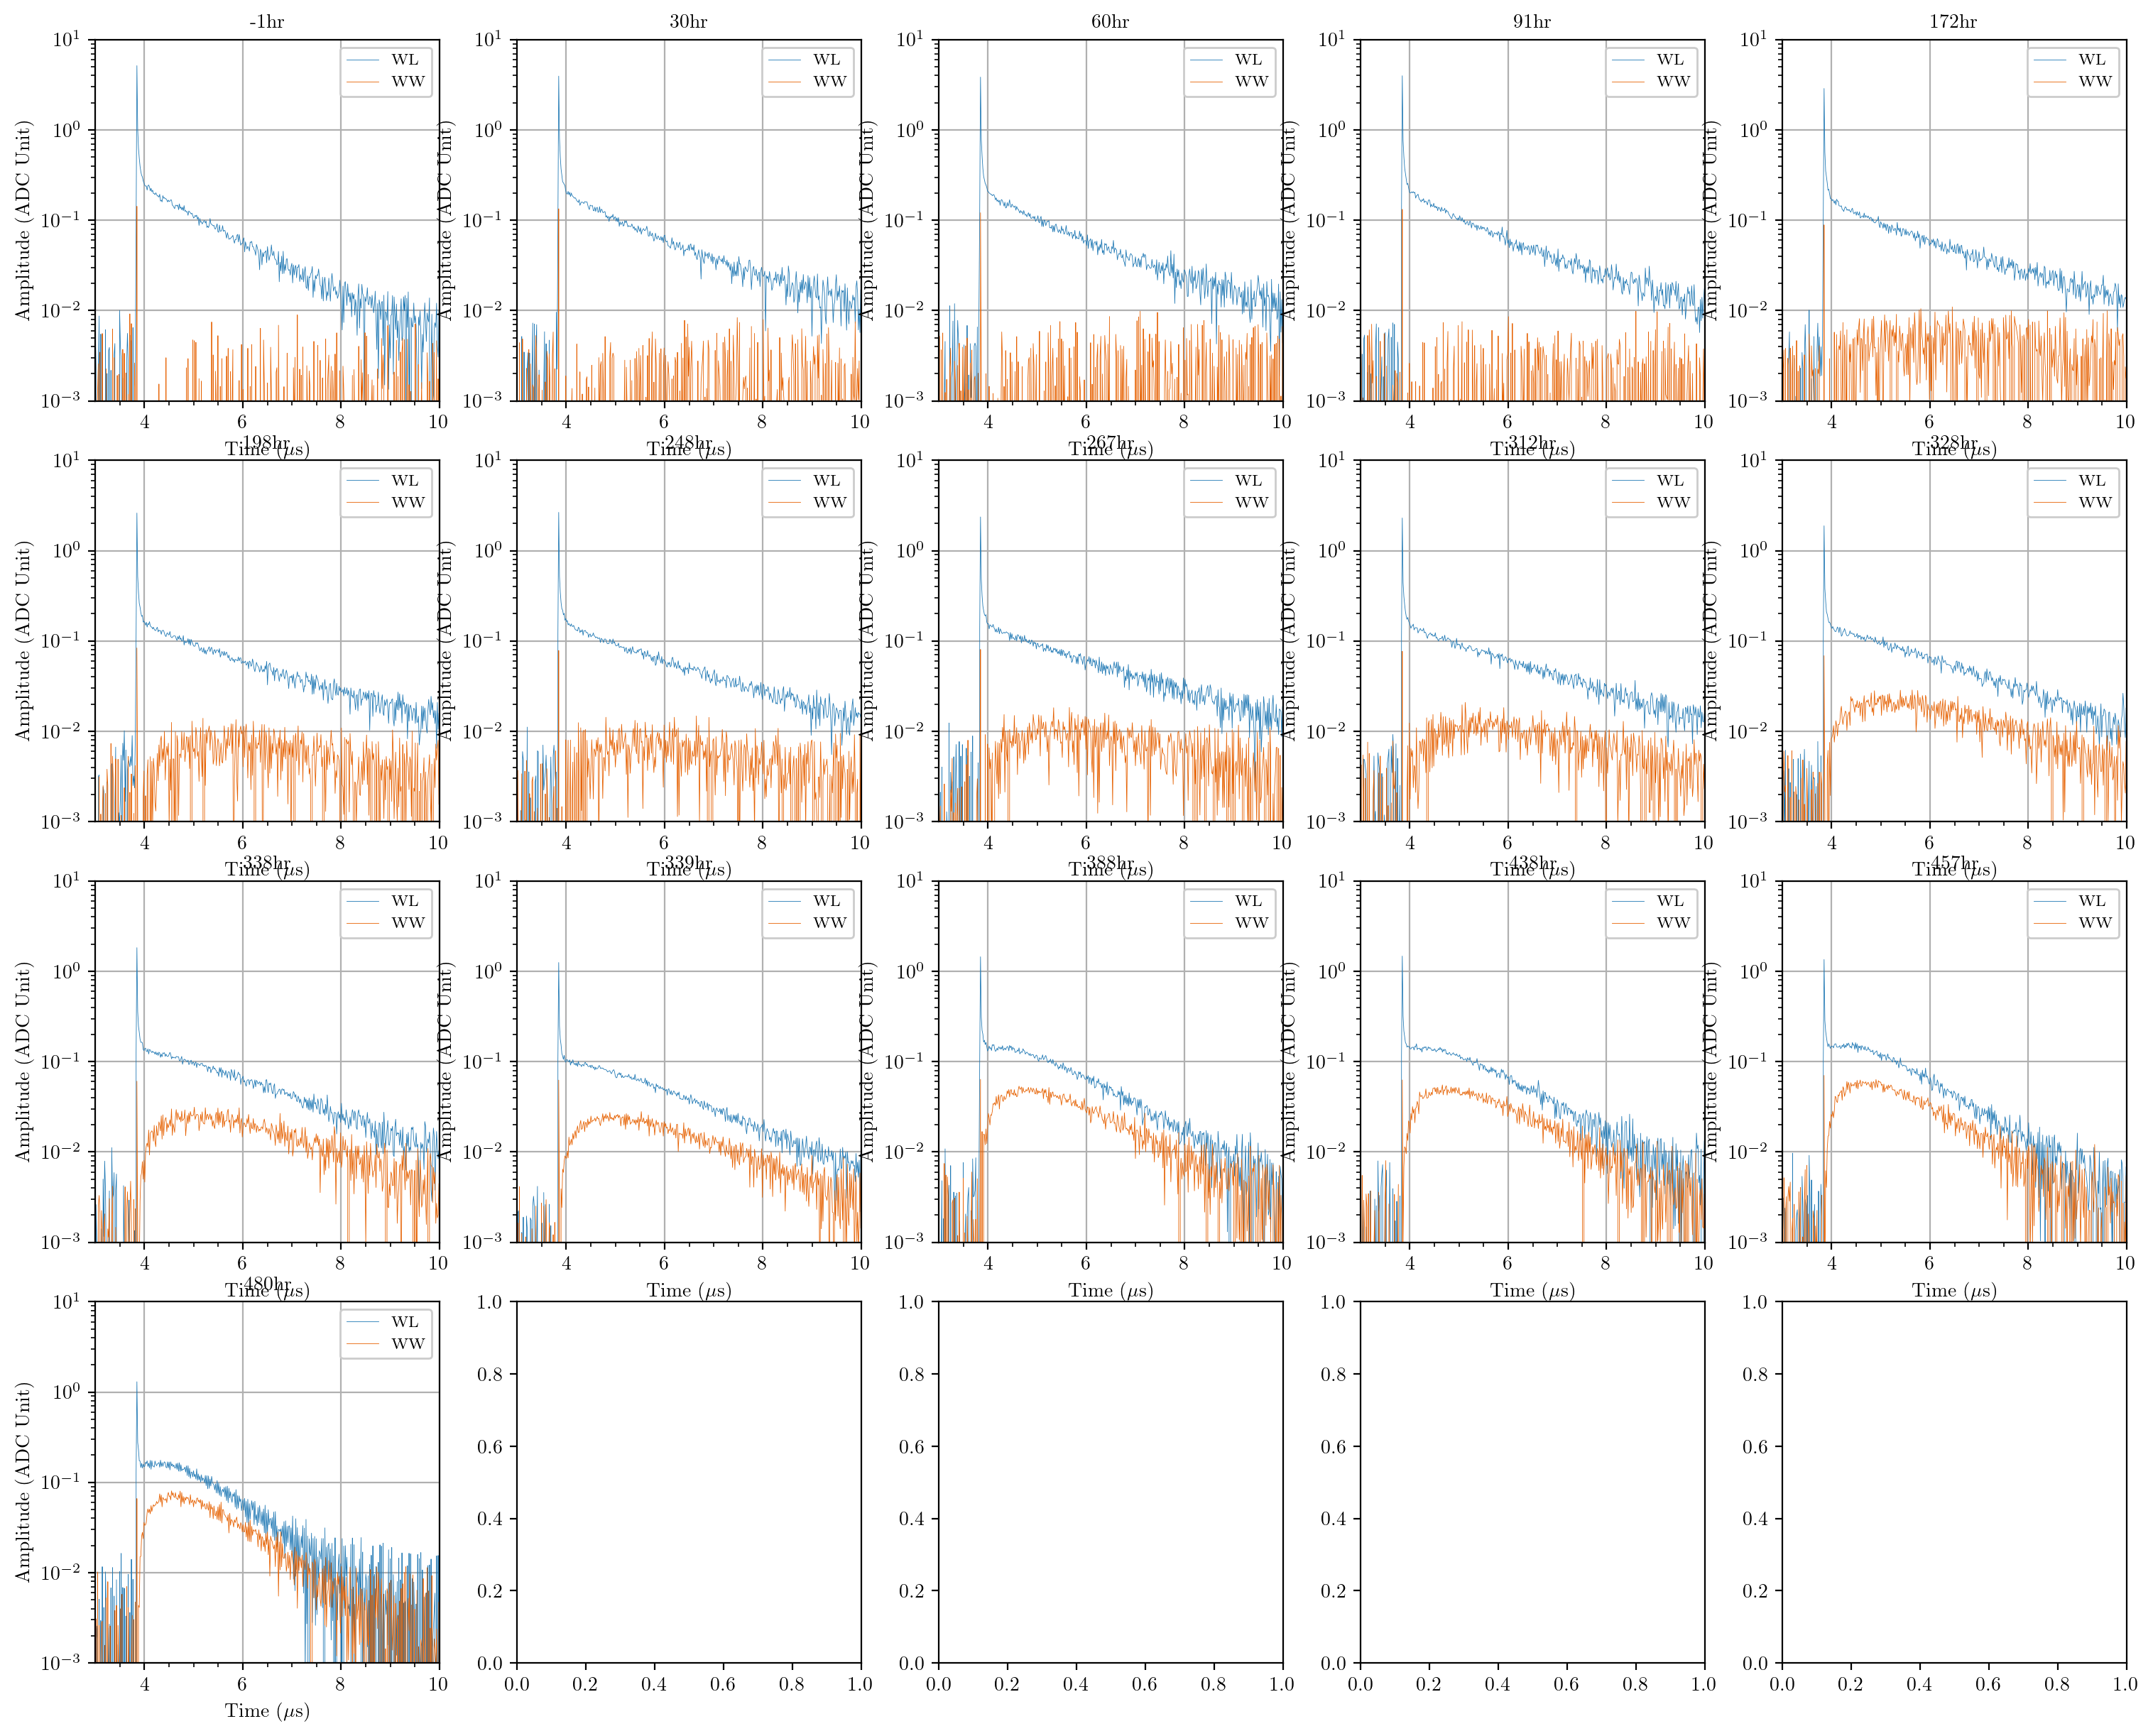

In [25]:
# Make plots for all datasets
# Summed scintillation waveform
file_indices = np.arange(0,len(files),10)
nrows = (len(file_indices)+4)//5
fig, axs = plt.subplots(nrows, 5, sharex=False, sharey=False)
fig.set_size_inches(15, 3*nrows)
fig.tight_layout()

for i, i_file in enumerate(file_indices):
	f = files[i_file]
	axs[i//5, i%5].plot(
				data_scint[i_file][-1]['time_sub'],
				data_scint[i_file][-1]['sum_wf_sub_nofs'],
				linewidth=0.3,label=r'WL')
	axs[i//5, i%5].plot(
				data_scint[i_file][-1]['time_sub'],
				data_scint[i_file][-1]['sum_wf_sub_fs'],
				linewidth=0.3, label=r'WW')
	axs[i//5, i%5].set_xlim(3, 10)
	axs[i//5, i%5].set_ylim(1e-3, 1e1)
	axs[i//5, i%5].set_yscale('log')
	axs[i//5, i%5].minorticks_on()
	axs[i//5, i%5].grid()
	axs[i//5, i%5].set_title(f'{hr_from_inject[i_file]:.0f}hr')
	axs[i//5, i%5].legend(loc='upper right')
	axs[i//5, i%5].set_xlabel(r'Time ($\mu$s)')
	axs[i//5, i%5].set_ylabel(r'Amplitude (ADC Unit)')

## WL + WW simultaneous fit

In [26]:
file_indices = np.arange(1,len(files)) # exclude 0ppm data
t0 = 3.84
pars_all, perrs_all = [], []

for i in file_indices:
	# error estimate
	pretrg = 3.5 #us
	err_wl = np.std(data_scint[i][-1]['sum_wf_sub_nofs'][data_scint[i][-1]['time_sub']<pretrg])
	data_scint[i][-1]['sum_wf_sub_nofs_err'] = err_wl
	err_ww = np.std(data_scint[i][-1]['sum_wf_sub_fs'][data_scint[i][-1]['time_sub']<pretrg])
	data_scint[i][-1]['sum_wf_sub_fs_err'] = err_ww
	# set fit range
	fit_range = [4.2, 12] #us
	data_scint[i][-1]['fit_range_ww'] = fit_range
	data_scint[i][-1]['fit_range_wl'] = fit_range
	range_arr = (data_scint[i][-1]['time_sub']<fit_range[1]) & (data_scint[i][-1]['time_sub']>fit_range[0])
	# fit setup
	xdata = [
		data_scint[i][-1]['time_sub'][range_arr],
		data_scint[i][-1]['time_sub'][range_arr]
	]
	ydata = [
		data_scint[i][-1]['sum_wf_sub_nofs'][range_arr] + 0.015*data_scint[i][-1]['sum_wf_sub_fs'][range_arr],
		data_scint[i][-1]['sum_wf_sub_fs'][range_arr] + 0.015*data_scint[i][-1]['sum_wf_sub_nofs'][range_arr]
	]
	yerr = [
		err_wl*np.ones(np.sum(range_arr)), 
		err_ww*np.ones(np.sum(range_arr))
	]
	xdata = np.vstack([np.concatenate(xdata),np.concatenate([np.ones_like(xdata[j])*j for j in range(len(xdata))])]).T
	ydata = np.concatenate(ydata)
	yerr = np.concatenate(yerr)
	p0 = [
     	np.sum(data_scint[i][-1]['sum_wf_sub_nofs'][range_arr])/2,
		np.sum(data_scint[i][-1]['sum_wf_sub_nofs'][range_arr])/2,
		np.sum(data_scint[i][-1]['sum_wf_sub_fs'][range_arr]),
		0.9,
  		2 if i<50 else 1.2
       ]
	# fit	
	popt, pcov = curve_fit(lambda x,*p: func.wl_ww_model(x,t0,*p), xdata, ydata, p0=p0, sigma=yerr, maxfev=10000)
	perr = np.array([func.error_distance(df=len(p0), sigma=1)*pcov[j,j]**0.5 for j in range(len(popt))])
	if popt[3]>popt[4]:
		popt[3],popt[4] = popt[4],popt[3]
		perr[3],perr[4] = perr[4],perr[3]
	print(f'{i} {hr_from_inject[i]:.0f}hr {p0} {popt} {perr}')
	pars_all.append(popt)
	perrs_all.append(perr)

1 2hr [9.791962627604294, 9.791962627604294, 0.21514705557294683, 0.9, 2] [ 45.74606347 -20.43238349   0.59458744   1.13470836   3.35304392] [9.74219729 9.28451899 0.19780877 0.21348899 0.77489787]
2 5hr [9.839684692405124, 9.839684692405124, 0.22643262056025787, 0.9, 2] [ 47.089494   -21.72503865   0.64034518   1.26838348   3.57187658] [14.21349532 13.63654858  0.2301575   0.24949922  1.14033638]
3 8hr [9.823191026897607, 9.823191026897607, 0.21457266219058793, 0.9, 2] [ 46.48053204 -21.09728607   0.60996003   1.19010546   3.47197635] [11.13113333 10.62721548  0.19954512  0.22313693  0.89219253]
4 11hr [9.924541481775647, 9.924541481775647, 0.23257058736786523, 0.9, 2] [ 46.79852156 -21.16203437   0.62265403   1.18050863   3.42384917] [10.92011122 10.43518998  0.20310909  0.21778949  0.85812314]
5 14hr [9.824331430626449, 9.824331430626449, 0.23451803289127965, 0.9, 2] [ 44.89825271 -19.56754973   0.6130618    1.14371865   3.30075646] [8.88706658 8.47598033 0.18342356 0.20562674 0.707

115 362hr [9.235049845833757, 9.235049845833757, 6.549897341011895, 0.9, 1.2] [ 5.68785546 16.13422031  7.20197124  0.70707702  1.80738791] [0.60412398 0.69269362 0.15421936 0.06355203 0.07853302]
116 367hr [9.097415460160123, 9.097415460160123, 7.773512591910553, 0.9, 1.2] [ 4.73562387 16.76001321  8.54104477  0.60272254  1.42967253] [0.53588363 0.57378129 0.14719401 0.04763297 0.05775063]
117 372hr [8.898221686135312, 8.898221686135312, 7.741504588541972, 0.9, 1.2] [ 4.6244019  16.42897144  8.48925386  0.60332147  1.41606296] [0.56324128 0.61108005 0.15286509 0.05120473 0.06465213]
118 377hr [9.016030860830856, 9.016030860830856, 7.727170309586306, 0.9, 1.2] [ 4.56700874 16.72723723  8.47573206  0.60236412  1.40559281] [0.60506924 0.65902778 0.15955863 0.05444837 0.07029524]
119 383hr [8.871525973136972, 8.871525973136972, 7.718678421495748, 0.9, 1.2] [ 4.21332221 16.6951706   8.50116544  0.57609861  1.43620068] [0.55588019 0.58687042 0.16086571 0.04944882 0.06069925]
120 388hr [9.05

/home/as111/sipm-analysis/sipm/util/functions.py:59: RuntimeWarning: overflow encountered in exp
  return a1/tau_ar*np.exp(-t/tau_ar)*16e-3 + ww_model(t,a2,tau_ar,tau_arxe)
/home/as111/sipm-analysis/sipm/util/functions.py:59: RuntimeWarning: overflow encountered in multiply
  return a1/tau_ar*np.exp(-t/tau_ar)*16e-3 + ww_model(t,a2,tau_ar,tau_arxe)
/home/as111/sipm-analysis/sipm/util/functions.py:53: RuntimeWarning: overflow encountered in exp
  return a/(tau_arxe-tau_ar)*(np.exp(-t/tau_arxe)-np.exp(-t/tau_ar)) * 16e-3
/home/as111/miniconda3/envs/sipm/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:504: RuntimeWarning: overflow encountered in multiply
  return transform * (func(xdata, *params) - ydata)


## Xe concentration evolution

Text(0.5, 1.0, 'Run 2')

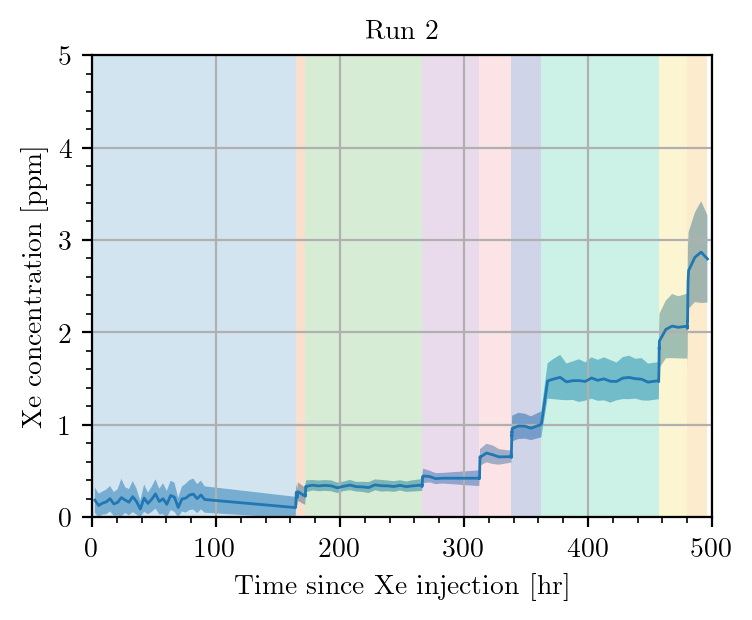

In [27]:
conc_est = np.array([(1/np.abs(p[4]) - tau_arxe0_2**-1)/k_rate2 for p in pars_all])
conc_est_err = np.array([np.abs(c*(e[4]/p[4]/k_rate2)) for e,p,c in zip(perrs_all,pars_all,conc_est)])
plt.fill_between(np.array(hr_from_inject)[file_indices], conc_est+conc_est_err, conc_est-conc_est_err,alpha=0.5)
plt.plot(np.array(hr_from_inject)[file_indices], conc_est, linewidth=1)
plt.grid()
plt.minorticks_on()
plt.xlabel('Time since Xe injection [hr]')
plt.ylabel('Xe concentration [ppm]')
ylims = [0,5]
plt.ylim(*ylims)

for i,t in enumerate(hr_dt_xe):
	if i==0:
		plt.axvspan(0,t,*ylims,alpha=0.2,color=f'C{i}',lw=0)
	else:
		plt.axvspan(hr_dt_xe[i-1],t,*ylims,alpha=0.2,color=f'C{i}',lw=0)
plt.axvspan(hr_dt_xe[-1],hr_from_inject[-1],*ylims,alpha=0.2,color=f'C{len(hr_dt_xe)}',lw=0)
plt.title('Run 2')